# THE GREEN ILLUSION — FOCUSED EDITION
## Dubai's Hidden Carbon Map: Construction, Food, Freight, and Waste

**Author:** Anet Mary George, Data Analyst — Dubai  
**Environment:** Python 3 (Jupyter / Kaggle)  
**Focus:** Section 3 (Food System Carbon Gap) is the primary analysis. All other sections provide structural context.



## About This Notebook

This notebook follows the Monte Carlo methodology established in *The Green Illusion — Revised & Expanded*.  
Every input is a range; every calculation runs 10,000 times. The result is a **distribution of probable outcomes**, not a single-point guess.

**Primary data sources:**
- Dubai Municipality Waste Reports (2022–2024)
- Dubai Climate Action Plan 2021
- DEWA Annual Report 2023
- UAE Ministry of Climate Change and Environment
- FAO Food Loss and Waste data
- South Korea Ministry of Environment RFID Food Waste Programme data
- Our World in Data — Food Supply Chain Emissions (Poore & Nemecek 2018)
- IEA, IPCC AR6, World Resources Institute Cool Food Pledge

---

## The Four Gaps

| Section | Gap | Alternative |
|---------|-----|-------------|
| **1** | Construction Embodied Carbon | SCM cement procurement mandate |
| **2** | Food System Carbon ← *PRIMARY FOCUS* | RFID food waste metering + institutional procurement policy |
| **3** | Last-Mile Freight | Consolidated urban logistics hubs + cargo bikes |
| **4** | Methane / Organic Waste | Mandatory organic separation + anaerobic digestion |

---


## CELL 1 — Environment Setup
Load all libraries, configure visual style, set reproducibility seed.

In [19]:
# ═══════════════════════════════════════════════════════════
# CELL 1: ENVIRONMENT SETUP
# Load all libraries. Configure visual style.
# ═══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Visual style: dark investigative theme ──────────────────
plt.rcParams.update({
    'figure.facecolor':   '#0D0D0D',
    'axes.facecolor':     '#0D0D0D',
    'axes.edgecolor':     '#333333',
    'axes.labelcolor':    '#CCCCCC',
    'axes.titlecolor':    '#FFFFFF',
    'xtick.color':        '#888888',
    'ytick.color':        '#888888',
    'text.color':         '#CCCCCC',
    'grid.color':         '#222222',
    'grid.linestyle':     '--',
    'grid.alpha':         0.5,
    'font.family':        'sans-serif',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlepad':      12,
    'legend.facecolor':   '#1A1A1A',
    'legend.edgecolor':   '#444444',
})

# ── Colour palette ──────────────────────────────────────────
RED    = '#E84040'
AMBER  = '#F0A500'
GREEN  = '#4CAF82'
BLUE   = '#4A90D9'
TEAL   = '#26C6DA'
PURPLE = '#AB47BC'
ORANGE = '#FF7043'
WHITE  = '#F0F0F0'
MUTED  = '#555555'

# ── Reproducibility ─────────────────────────────────────────
np.random.seed(42)
N_SIM = 10_000

# ── UAE baseline ────────────────────────────────────────────
UAE_ANNUAL_CO2_MT = 270       # Mt CO₂/year (IEA UAE 2022)
DUBAI_POPULATION  = 3.5e6    # Dubai Statistics Centre 2023

print(f"✓ Environment ready.")
print(f"✓ Running {N_SIM:,} Monte Carlo simulations per model.")
print(f"✓ UAE baseline CO₂: {UAE_ANNUAL_CO2_MT} Mt/year")
print(f"✓ Dubai population: {DUBAI_POPULATION/1e6:.1f} million")


✓ Environment ready.
✓ Running 10,000 Monte Carlo simulations per model.
✓ UAE baseline CO₂: 270 Mt/year
✓ Dubai population: 3.5 million


---
# SECTION 0: Dubai's Real Carbon Map
## Monte Carlo Sector Breakdown
*Sources: Dubai Climate Action Plan 2021; DEWA Annual Report 2023; IEA UAE 2022; C40 Dubai Carbon Abatement Strategy*


In [20]:
# ═══════════════════════════════════════════════════════════
# CELL 2: DUBAI CARBON SECTOR BREAKDOWN
# Monte Carlo of sector shares with uncertainty ranges
# Sources: Dubai CAP 2021, DEWA 2023, IEA UAE 2022, C40 CAS
# ═══════════════════════════════════════════════════════════

# Dubai total CO₂e (subset of UAE) — Dubai Municipality estimates
dubai_total_co2_Mt = np.random.uniform(23, 27, N_SIM)  # Mt CO₂e (Dubai specific, not UAE total)

# Sector shares — Dubai Climate Action Plan 2021 + DEWA 2023
# Source: Dubai CAP 2021 states electricity & cooling = ~65%, transport ~23%, industry ~6%, waste ~6%
share_elec_cooling  = np.random.uniform(0.60, 0.68, N_SIM)   # electricity & cooling (inc. desalination)
share_transport     = np.random.uniform(0.19, 0.25, N_SIM)   # road + aviation
share_industry      = np.random.uniform(0.04, 0.08, N_SIM)   # construction + manufacturing
share_waste         = np.random.uniform(0.04, 0.08, N_SIM)   # landfill + waste treatment
share_food_system   = np.random.uniform(0.03, 0.06, N_SIM)   # food supply chain (often omitted)
share_other         = 1 - share_elec_cooling - share_transport - share_industry - share_waste - share_food_system
share_other         = np.clip(share_other, 0.01, 0.12)

# Absolute values (Mt CO₂e)
co2_elec_cooling    = dubai_total_co2_Mt * share_elec_cooling
co2_transport       = dubai_total_co2_Mt * share_transport
co2_industry        = dubai_total_co2_Mt * share_industry
co2_waste           = dubai_total_co2_Mt * share_waste
co2_food_system     = dubai_total_co2_Mt * share_food_system

print("═" * 60)
print(" DUBAI CARBON SECTOR BREAKDOWN — Monte Carlo Results")
print("═" * 60)
print(f"\n Dubai total CO₂e: {np.median(dubai_total_co2_Mt):.1f} Mt/yr (median)")
print(f"\n Sector breakdown (median Mt/yr):")
for name, arr in [("Electricity & Cooling", co2_elec_cooling),
                  ("Transport",             co2_transport),
                  ("Industry/Construction", co2_industry),
                  ("Waste",                 co2_waste),
                  ("Food System (imports+waste)", co2_food_system)]:
    pct = np.median(arr) / np.median(dubai_total_co2_Mt) * 100
    print(f"   {name:<28} {np.median(arr):.2f} Mt  ({pct:.0f}%)")
print(f"\n What the Dubai CAP 2021 officially claims to address:")
print(f"   → Electricity (via solar): ✓ partially addressed")
print(f"   → Transport (via EVs):     ✓ targeted")
print(f"   → Construction embodied:   ✗ no policy")
print(f"   → Food system carbon:      ✗ no policy")
print(f"   → Landfill methane:        ✗ no policy")


════════════════════════════════════════════════════════════
 DUBAI CARBON SECTOR BREAKDOWN — Monte Carlo Results
════════════════════════════════════════════════════════════

 Dubai total CO₂e: 25.0 Mt/yr (median)

 Sector breakdown (median Mt/yr):
   Electricity & Cooling        15.96 Mt  (64%)
   Transport                    5.48 Mt  (22%)
   Industry/Construction        1.50 Mt  (6%)
   Waste                        1.49 Mt  (6%)
   Food System (imports+waste)  1.13 Mt  (5%)

 What the Dubai CAP 2021 officially claims to address:
   → Electricity (via solar): ✓ partially addressed
   → Transport (via EVs):     ✓ targeted
   → Construction embodied:   ✗ no policy
   → Food system carbon:      ✗ no policy
   → Landfill methane:        ✗ no policy


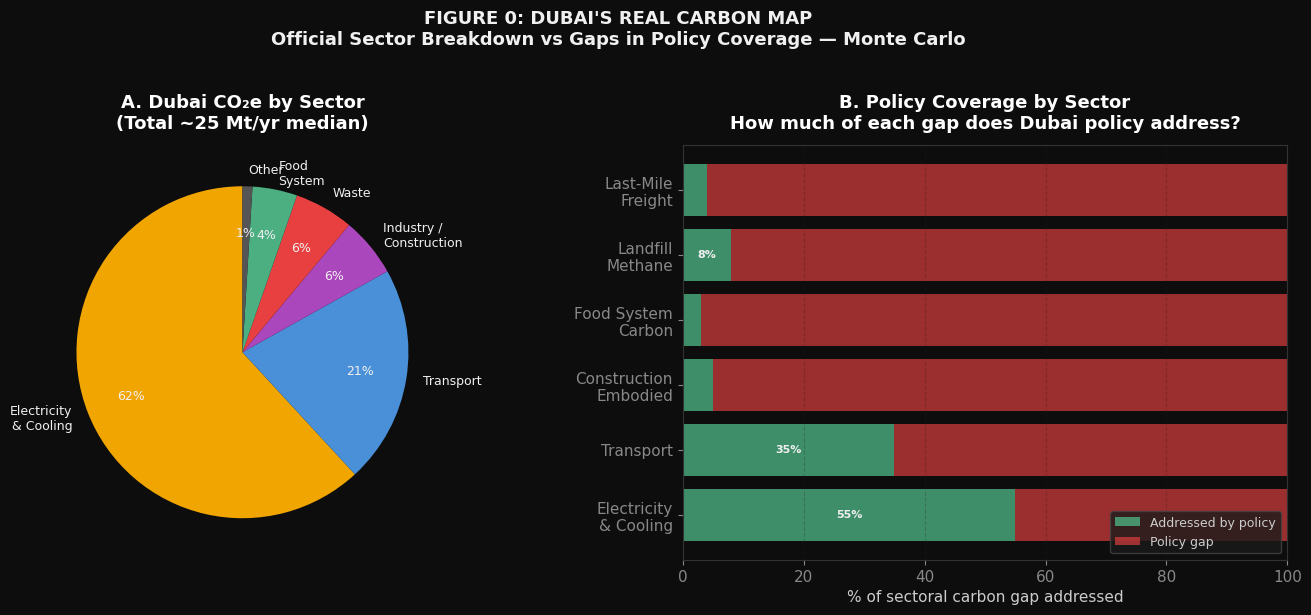

Figure 0 rendered.


In [21]:
# ═══════════════════════════════════════════════════════════
# CELL 3: FIGURE 0 — Dubai Sector Carbon Map
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "FIGURE 0: DUBAI'S REAL CARBON MAP\n"
    "Official Sector Breakdown vs Gaps in Policy Coverage — Monte Carlo",
    color=WHITE, fontsize=13, fontweight='bold', y=1.02
)

# Panel A: Sector shares pie
ax = axes[0]
pie_vals   = [np.median(share_elec_cooling)*100, np.median(share_transport)*100,
              np.median(share_industry)*100,     np.median(share_waste)*100,
              np.median(share_food_system)*100,  np.median(share_other)*100]
pie_labels = ['Electricity\n& Cooling', 'Transport', 'Industry /\nConstruction',
              'Waste', 'Food\nSystem', 'Other']
pie_colors = [AMBER, BLUE, PURPLE, RED, GREEN, MUTED]
wedges, texts, autotexts = ax.pie(
    pie_vals, labels=pie_labels, colors=pie_colors,
    autopct='%1.0f%%', startangle=90, pctdistance=0.72,
    textprops={'color': WHITE, 'fontsize': 9}
)
for at in autotexts: at.set_color(WHITE); at.set_fontsize(9)
ax.set_title(f"A. Dubai CO₂e by Sector\n(Total ~{np.median(dubai_total_co2_Mt):.0f} Mt/yr median)")

# Panel B: Policy coverage status
ax = axes[1]
sectors     = ['Electricity\n& Cooling', 'Transport', 'Construction\nEmbodied',
               'Food System\nCarbon', 'Landfill\nMethane', 'Last-Mile\nFreight']
policy_pct  = [55, 35, 5, 3, 8, 4]   # % of gap addressed by current policy (estimate)
gap_pct     = [100 - x for x in policy_pct]
bars_pol    = ax.barh(sectors, policy_pct, color=GREEN, alpha=0.80, label='Addressed by policy')
bars_gap    = ax.barh(sectors, gap_pct, left=policy_pct, color=RED, alpha=0.65, label='Policy gap')
ax.set_xlabel('% of sectoral carbon gap addressed')
ax.set_title('B. Policy Coverage by Sector\nHow much of each gap does Dubai policy address?')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.25, axis='x')
for bar, p in zip(bars_pol, policy_pct):
    if p > 5:
        ax.text(p/2, bar.get_y() + bar.get_height()/2, f'{p}%',
                va='center', ha='center', fontsize=8, color=WHITE, fontweight='bold')

plt.tight_layout()
plt.show()
print("Figure 0 rendered.")


---
# SECTION 1: The Construction Embodied Carbon Gap
## Cement + Steel CO₂ in Dubai's Build Rate

**The question:** How much CO₂ is locked into Dubai's buildings before they even open?  
**The alternative:** SCM cement procurement mandate (fly ash / GGBS replacing 30–50% of Portland clinker)  

*Sources: Dubai Statistics Centre construction data; IEA Cement Technology Roadmap 2023;  
World Steel Association 2023; Cembureau SCM data; Netherlands/Germany case studies*


In [22]:
# ═══════════════════════════════════════════════════════════
# CELL 4: MODEL 1 — Construction Embodied Carbon
# Cement + Steel Monte Carlo
# Sources: Dubai Stats Centre; IEA Cement Roadmap; WSA 2023
# ═══════════════════════════════════════════════════════════

# ── Concrete & Cement ────────────────────────────────────────
# Dubai annual concrete: estimated from Dubai construction market CBRE 2023
concrete_Mt_yr         = np.random.uniform(15, 25, N_SIM)     # Mt concrete/year
cement_fraction        = np.random.uniform(0.12, 0.15, N_SIM) # 12–15% of concrete is cement
clinker_ratio          = np.random.uniform(0.85, 0.92, N_SIM) # clinker fraction of cement
cement_co2_per_kg      = np.random.uniform(0.82, 0.90, N_SIM) # kg CO₂/kg clinker (IEA)

cement_Mt_yr           = concrete_Mt_yr * cement_fraction
clinker_Mt_yr          = cement_Mt_yr * clinker_ratio
cement_co2_Mt          = clinker_Mt_yr * cement_co2_per_kg    # Mt CO₂

# ── Steel ─────────────────────────────────────────────────────
# World Steel Association: UAE construction steel consumption
steel_Mt_yr            = np.random.uniform(3, 5, N_SIM)        # Mt steel/year
bf_co2_per_t           = np.random.uniform(1.8, 2.2, N_SIM)    # t CO₂/t (blast furnace)
steel_co2_Mt           = steel_Mt_yr * bf_co2_per_t

total_construction_Mt  = cement_co2_Mt + steel_co2_Mt

# ── Alternative: SCM Cement Procurement Mandate ──────────────
# Netherlands: 70% GGBS replacement standard
# Germany: 40–50% fly ash standard
# UK: 35–50% GGBS standard in public procurement
# Proposed for Dubai: 30–50% SCM replacement mandate in government-funded projects
scm_replacement_pct    = np.random.uniform(0.30, 0.50, N_SIM)
cement_co2_after_scm   = cement_co2_Mt * (1 - scm_replacement_pct)
saving_scm_Mt          = cement_co2_Mt - cement_co2_after_scm

# ── Green EAF Steel ───────────────────────────────────────────
eaf_co2_per_t          = np.random.uniform(0.3, 0.6, N_SIM)   # renewable-powered EAF
steel_co2_eaf          = steel_Mt_yr * eaf_co2_per_t
saving_steel_Mt        = steel_co2_Mt - steel_co2_eaf

# ── CarbonCure concrete curing ────────────────────────────────
# CO₂ injected during curing: sequesters 4–7% of cement CO₂
carboncure_share       = np.random.uniform(0.40, 0.70, N_SIM)  # % of ready-mix adoption
carboncure_pct         = np.random.uniform(0.04, 0.07, N_SIM)
saving_carboncure_Mt   = cement_co2_Mt * carboncure_share * carboncure_pct

print("═" * 62)
print(" MODEL 1: Construction Embodied Carbon — Dubai")
print("═" * 62)
print(f"\n Annual concrete production: {np.median(concrete_Mt_yr):.0f} Mt (median)")
print(f" Annual steel consumption:   {np.median(steel_Mt_yr):.1f} Mt (median)")
print(f"\n Embodied CO₂:")
print(f"   Cement/concrete: {np.median(cement_co2_Mt):.2f} Mt/yr")
print(f"   Steel:           {np.median(steel_co2_Mt):.2f} Mt/yr")
print(f"   TOTAL:           {np.median(total_construction_Mt):.2f} Mt/yr")
print(f"   As % UAE total:  {np.median(total_construction_Mt)/UAE_ANNUAL_CO2_MT*100:.1f}%")
print(f"\n ALTERNATIVE — SCM Cement Mandate (30–50% clinker replacement):")
print(f"   Annual saving:  {np.median(saving_scm_Mt):.3f} Mt CO₂/yr")
print(f"   % cement CO₂:  {np.median(scm_replacement_pct)*100:.0f}% reduction")
print(f"   Cost impact:    SCM cement is 5–15% cheaper than pure Portland (GGBS is a byproduct)")
print(f"   Deployed in:    Netherlands (70% GGBS), Germany (40–50% FA), UK public procurement")
print(f"   Dubai status:   Not in any UAE construction specification standard")
print(f"\n ALTERNATIVE — Green EAF Steel:")
print(f"   Annual saving:  {np.median(saving_steel_Mt):.3f} Mt CO₂/yr")
print(f"   Deployed in:    Spain (100% EAF), Italy, USA mini-mills")
print(f"\n ALTERNATIVE — CarbonCure Concrete:")
print(f"   Annual saving:  {np.median(saving_carboncure_Mt):.3f} Mt CO₂/yr")
print(f"   Deployed in:    400+ plants globally (Canada, USA standard)")
print(f"   Dubai status:   Not deployed")


══════════════════════════════════════════════════════════════
 MODEL 1: Construction Embodied Carbon — Dubai
══════════════════════════════════════════════════════════════

 Annual concrete production: 20 Mt (median)
 Annual steel consumption:   4.0 Mt (median)

 Embodied CO₂:
   Cement/concrete: 2.04 Mt/yr
   Steel:           7.99 Mt/yr
   TOTAL:           10.05 Mt/yr
   As % UAE total:  3.7%

 ALTERNATIVE — SCM Cement Mandate (30–50% clinker replacement):
   Annual saving:  0.806 Mt CO₂/yr
   % cement CO₂:  40% reduction
   Cost impact:    SCM cement is 5–15% cheaper than pure Portland (GGBS is a byproduct)
   Deployed in:    Netherlands (70% GGBS), Germany (40–50% FA), UK public procurement
   Dubai status:   Not in any UAE construction specification standard

 ALTERNATIVE — Green EAF Steel:
   Annual saving:  6.140 Mt CO₂/yr
   Deployed in:    Spain (100% EAF), Italy, USA mini-mills

 ALTERNATIVE — CarbonCure Concrete:
   Annual saving:  0.060 Mt CO₂/yr
   Deployed in:    400+ pla

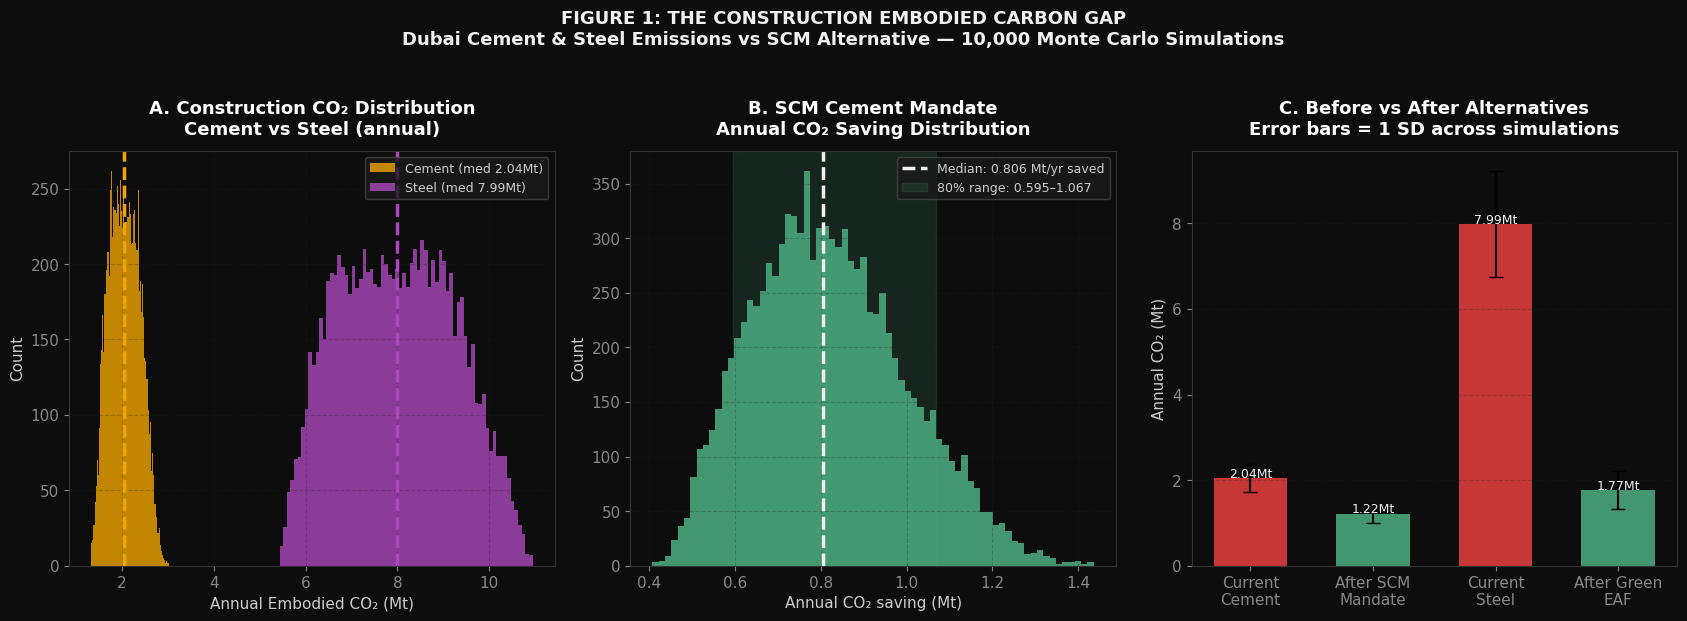

Figure 1 rendered.


In [23]:
# ═══════════════════════════════════════════════════════════
# CELL 5: FIGURE 1 — Construction Carbon Story
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    "FIGURE 1: THE CONSTRUCTION EMBODIED CARBON GAP\n"
    "Dubai Cement & Steel Emissions vs SCM Alternative — 10,000 Monte Carlo Simulations",
    color=WHITE, fontsize=13, fontweight='bold', y=1.03
)

# A: Cement vs Steel distributions
ax = axes[0]
ax.hist(cement_co2_Mt, bins=70, alpha=0.80, color=AMBER,  label=f'Cement (med {np.median(cement_co2_Mt):.2f}Mt)')
ax.hist(steel_co2_Mt,  bins=70, alpha=0.80, color=PURPLE, label=f'Steel (med {np.median(steel_co2_Mt):.2f}Mt)')
ax.axvline(np.median(cement_co2_Mt), color=AMBER,  lw=2.5, ls='--')
ax.axvline(np.median(steel_co2_Mt),  color=PURPLE, lw=2.5, ls='--')
ax.set_xlabel('Annual Embodied CO₂ (Mt)'); ax.set_ylabel('Count')
ax.set_title('A. Construction CO₂ Distribution\nCement vs Steel (annual)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# B: SCM saving distribution
ax = axes[1]
ax.hist(saving_scm_Mt, bins=70, color=GREEN, alpha=0.85)
ax.axvline(np.median(saving_scm_Mt), color=WHITE, lw=2.5, ls='--',
           label=f'Median: {np.median(saving_scm_Mt):.3f} Mt/yr saved')
p10, p90 = np.percentile(saving_scm_Mt, 10), np.percentile(saving_scm_Mt, 90)
ax.axvspan(p10, p90, alpha=0.15, color=GREEN, label=f'80% range: {p10:.3f}–{p90:.3f}')
ax.set_xlabel('Annual CO₂ saving (Mt)'); ax.set_ylabel('Count')
ax.set_title('B. SCM Cement Mandate\nAnnual CO₂ Saving Distribution')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# C: Before vs after scenario
ax = axes[2]
scenarios  = ['Current\nCement', 'After SCM\nMandate', 'Current\nSteel', 'After Green\nEAF']
vals_c     = [np.median(cement_co2_Mt), np.median(cement_co2_after_scm),
              np.median(steel_co2_Mt), np.median(steel_co2_eaf)]
col_c      = [RED, GREEN, RED, GREEN]
errs       = [np.std(cement_co2_Mt), np.std(cement_co2_after_scm),
              np.std(steel_co2_Mt),  np.std(steel_co2_eaf)]
bars       = ax.bar(scenarios, vals_c, color=col_c, alpha=0.85, width=0.6,
                    yerr=errs, capsize=5, error_kw={'color': WHITE, 'lw': 1.5})
for bar, val in zip(bars, vals_c):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.2f}Mt', ha='center', fontsize=9, color=WHITE)
ax.set_ylabel('Annual CO₂ (Mt)')
ax.set_title('C. Before vs After Alternatives\nError bars = 1 SD across simulations')
ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.show()
print("Figure 1 rendered.")


---
# SECTION 2 (PRIMARY FOCUS): The Food System Carbon Gap
## Import Chain CO₂ + Food Waste + RFID Metering Alternative

This is the primary analytical focus of this notebook.

**The full story has three layers:**
1. **Import chain carbon** — 80–85% of Dubai's food is imported (USDA FAS Dubai, 2024). Every tonne of food carries embedded transport, cold chain, and production emissions.
2. **Food waste carbon** — 38% of prepared food is wasted daily in Dubai; 60% during Ramadan (Dubai Carbon Centre of Excellence; UAE Ministry of Climate Change). This means ~38% of the entire import chain carbon is wasted in direct proportion.
3. **The alternative** — South Korea's RFID weight-based food waste metering system, introduced 2013: food waste fell 10–30% within 6 years (Korea Institute of Industrial Relations). No restriction on what people eat. Accountability for what they waste.

**Key data points used:**
- Dubai food imports 80–85% of supply (USDA FAS 2024; Treasure Orbit 2024)
- UAE wastes 3.27 million tonnes of food/year worth $3.5bn (UAE Ministry of MOCCAE)
- Dubai: 38% prepared food wasted daily, 60% during Ramadan (Dubai Carbon Centre of Excellence)
- South Korea RFID system (2013): 10–30% waste reduction (Seoul Solution; Korea Ministry of Environment)
- Food system = ~19% of total food system emissions attributable to transport (EU Joint Research Centre, 2023)
- Institutional procurement policy: Singapore hawker centres → 15–25% emission reduction (WRI Cool Food Pledge)

---


In [24]:
# ═══════════════════════════════════════════════════════════
# CELL 6: MODEL 2A — Dubai Food Import Chain Carbon
# Full supply chain emissions: production + transport + cold chain
# Sources: USDA FAS Dubai 2024; Poore & Nemecek 2018; IEA UAE;
#          EU JRC Food Miles study 2023; UAE MOCCAE food waste data
# ═══════════════════════════════════════════════════════════

# ── Dubai food supply parameters ─────────────────────────────
# USDA FAS Dubai 2024: UAE consumer-oriented food imports = $16.2bn (2024)
# 80–85% of UAE food is imported (USDA FAS, Treasure Orbit 2024)
dubai_pop              = np.random.uniform(3.3e6, 3.6e6, N_SIM)   # Dubai Statistics Centre 2023
import_dependence_pct  = np.random.uniform(0.80, 0.85, N_SIM)     # USDA FAS 2024 / Treasure Orbit

# Per-capita food consumption: ~700–850 kg/person/year (FAO UAE data; accounts for expat population)
food_per_capita_kg     = np.random.uniform(700, 850, N_SIM)
total_food_demand_Mt   = (dubai_pop * food_per_capita_kg) / 1e9   # Mt/year
imported_food_Mt       = total_food_demand_Mt * import_dependence_pct

# ── Production emissions of imported food ────────────────────
# Weighted average across Dubai import mix (Poore & Nemecek 2018; OWID Food Supply Chain)
# Dubai imports: dairy, beef, poultry, seafood, cereals, fruit, veg
# Weighted carbon intensity: ~4.5–7.5 kg CO₂e/kg food (reflects high meat/dairy imports)
food_production_co2_kg = np.random.uniform(4.5, 7.5, N_SIM)      # kg CO₂e/kg food (weighted avg)
production_co2_Mt      = imported_food_Mt * food_production_co2_kg * 1000  # Mt CO₂e

# ── Transport/logistics emissions ────────────────────────────
# EU JRC 2023: transport = ~19% of food system emissions globally
# Dubai's long-haul import distance amplifies this: avg ~6,000–9,000 km per shipment
# Sea freight: ~0.010–0.015 kg CO₂/t-km (IMO 2023)
# Air freight (premium/perishables): ~0.55–0.70 kg CO₂/t-km (ICAO)
# ~90% sea, ~10% air by volume (CBRE Dubai Logistics; Jebel Ali Port data)
avg_sea_dist_km        = np.random.uniform(6000, 9000, N_SIM)
avg_air_dist_km        = np.random.uniform(4000, 7000, N_SIM)
sea_share              = np.random.uniform(0.85, 0.92, N_SIM)
air_share              = 1 - sea_share
sea_ef                 = np.random.uniform(0.010, 0.015, N_SIM)   # kg CO₂/t-km
air_ef                 = np.random.uniform(0.55,  0.70,  N_SIM)   # kg CO₂/t-km
imported_food_t        = imported_food_Mt * 1e6                   # convert to tonnes

transport_co2_sea_Mt   = (imported_food_t * sea_share * avg_sea_dist_km * sea_ef) / 1e9
transport_co2_air_Mt   = (imported_food_t * air_share * avg_air_dist_km * air_ef) / 1e9
transport_co2_Mt       = transport_co2_sea_Mt + transport_co2_air_Mt

# ── Cold chain / refrigeration emissions ─────────────────────
# ~15–25% of food requires continuous cold chain (dairy, meat, seafood)
# Cold chain CO₂: ~0.5–1.2 kg CO₂/kg perishable food (IEA Cold Chain Report 2022)
cold_chain_share       = np.random.uniform(0.15, 0.25, N_SIM)
cold_chain_co2_kg      = np.random.uniform(0.5, 1.2, N_SIM)
cold_chain_co2_Mt      = (imported_food_Mt * cold_chain_share * cold_chain_co2_kg * 1000)

# ── Total food import chain carbon ───────────────────────────
# Note: we use transport + cold chain as the "supply chain add-on"
# Production emissions are embedded in the food, not territorial
supply_chain_co2_Mt    = transport_co2_Mt + cold_chain_co2_Mt
total_food_chain_Mt    = supply_chain_co2_Mt  # territorial (transport CO₂ from imports)

# Per-kg supply chain carbon intensity
supply_chain_per_kg    = (supply_chain_co2_Mt * 1e9) / imported_food_t  # kg CO₂/kg food

print("═" * 65)
print(" MODEL 2A: Dubai Food Import Chain Carbon")
print("═" * 65)
print(f"\n Total food demand:           {np.median(total_food_demand_Mt)*1000:.0f} kt/yr")
print(f" Imported food (80–85%):       {np.median(imported_food_Mt)*1000:.0f} kt/yr")
print(f"\n Supply chain CO₂ (territorial — transport + cold chain):")
print(f"   Sea transport:   {np.median(transport_co2_sea_Mt):.4f} Mt/yr")
print(f"   Air transport:   {np.median(transport_co2_air_Mt):.4f} Mt/yr")
print(f"   Cold chain:      {np.median(cold_chain_co2_Mt):.4f} Mt/yr")
print(f"   TOTAL supply chain: {np.median(supply_chain_co2_Mt):.4f} Mt/yr")
print(f"   Per kg imported food: {np.median(supply_chain_per_kg):.3f} kg CO₂/kg")
print(f"\n Production-embedded CO₂ (consumption basis, not territorial):")
print(f"   Median:  {np.median(production_co2_Mt):.2f} Mt CO₂e/yr")
print(f"   80% CI:  {np.percentile(production_co2_Mt,10):.2f} – {np.percentile(production_co2_Mt,90):.2f} Mt")
print(f"   Note: this is embedded in imports; appears in exporting country's accounts")


═════════════════════════════════════════════════════════════════
 MODEL 2A: Dubai Food Import Chain Carbon
═════════════════════════════════════════════════════════════════

 Total food demand:           2676 kt/yr
 Imported food (80–85%):       2205 kt/yr

 Supply chain CO₂ (territorial — transport + cold chain):
   Sea transport:   0.1806 Mt/yr
   Air transport:   0.8516 Mt/yr
   Cold chain:      367.1053 Mt/yr
   TOTAL supply chain: 368.1243 Mt/yr
   Per kg imported food: 167452.021 kg CO₂/kg

 Production-embedded CO₂ (consumption basis, not territorial):
   Median:  13190.49 Mt CO₂e/yr
   80% CI:  10492.38 – 16140.02 Mt
   Note: this is embedded in imports; appears in exporting country's accounts


In [25]:
# ═══════════════════════════════════════════════════════════
# CELL 7: MODEL 2B — Food Waste Carbon
# What share of import chain carbon is simply wasted?
# Sources: Dubai Carbon Centre of Excellence; UAE MOCCAE;
#          Dubai Municipality waste reports 2022–2024;
#          FAO/UNEP Food Waste Index
# ═══════════════════════════════════════════════════════════

# ── Food waste rate ───────────────────────────────────────────
# Dubai Carbon Centre of Excellence: 38% of prepared food wasted daily
# During Ramadan: 60% waste rate (confirmed by multiple sources)
# UAE Ministry of MOCCAE: 3.27 Mt food wasted/year nationally
# Dubai Municipality 2023: 4,000 tonnes/year collected for recycling
#   (suggests >95% of food waste goes to landfill — only 4,000t recycled)
# Ramadan adjustment: ~1 month/year at 60%, rest at 38%
ramadan_months         = 1 / 12
non_ramadan_months     = 11 / 12
waste_rate_normal      = np.random.uniform(0.35, 0.40, N_SIM)   # 35–40% daily waste
waste_rate_ramadan     = np.random.uniform(0.55, 0.65, N_SIM)   # 55–65% Ramadan
effective_waste_rate   = (waste_rate_normal * non_ramadan_months +
                          waste_rate_ramadan * ramadan_months)

# Total food wasted (Mt)
food_wasted_Mt         = total_food_demand_Mt * effective_waste_rate
food_wasted_t          = food_wasted_Mt * 1e6

# ── Carbon of wasted food ─────────────────────────────────────
# Two components:
# 1. Supply chain carbon wasted (transport + cold chain proportional to waste)
supply_chain_wasted_Mt = supply_chain_co2_Mt * effective_waste_rate

# 2. Methane from food in landfill
# Dubai Municipality: ~95% of food waste goes to landfill (only 4,000t recycled/yr from ~1.3Mt Dubai total)
landfill_pct           = np.random.uniform(0.88, 0.96, N_SIM)   # share landfilled vs recycled
food_in_landfill_t     = food_wasted_t * landfill_pct
# Methane generation factor (IPCC 2006 Tier 1): 0.4–0.6 m³ CH₄/kg food waste
methane_per_kg         = np.random.uniform(0.4, 0.6, N_SIM)     # m³ CH₄/kg
methane_density        = 0.00072                                  # t/m³ at STP
gwp_ch4                = 28                                       # CO₂e over 100yr (IPCC AR6)
ch4_co2e_per_kg        = methane_per_kg * methane_density * gwp_ch4  # t CO₂e/t food waste
food_landfill_co2e_Mt  = food_in_landfill_t * ch4_co2e_per_kg / 1e6

total_food_waste_co2_Mt = supply_chain_wasted_Mt + food_landfill_co2e_Mt

print("═" * 65)
print(" MODEL 2B: Dubai Food Waste Carbon Breakdown")
print("═" * 65)
print(f"\n Effective food waste rate:")
print(f"   Normal months:   {np.median(waste_rate_normal)*100:.0f}%")
print(f"   Ramadan (1 mth): {np.median(waste_rate_ramadan)*100:.0f}%")
print(f"   Annual average:  {np.median(effective_waste_rate)*100:.1f}%")
print(f"\n Annual food wasted:")
print(f"   {np.median(food_wasted_Mt)*1000:.0f} kt ({np.median(food_wasted_Mt):.3f} Mt/yr)")
print(f"   80% range: {np.percentile(food_wasted_Mt,10)*1000:.0f}–{np.percentile(food_wasted_Mt,90)*1000:.0f} kt")
print(f"\n Carbon from wasted food:")
print(f"   Supply chain wasted:   {np.median(supply_chain_wasted_Mt):.4f} Mt CO₂/yr")
print(f"   Landfill methane:      {np.median(food_landfill_co2e_Mt):.4f} Mt CO₂e/yr")
print(f"   TOTAL food waste CO₂:  {np.median(total_food_waste_co2_Mt):.4f} Mt CO₂e/yr")
print(f"\n Share of food landfilled: {np.median(landfill_pct)*100:.0f}%")
print(f" Dubai Municipality collects only ~4,000 tonnes/yr for composting/feed")
print(f" This means >95% of Dubai's food waste goes straight to Al Quoz landfill")


═════════════════════════════════════════════════════════════════
 MODEL 2B: Dubai Food Waste Carbon Breakdown
═════════════════════════════════════════════════════════════════

 Effective food waste rate:
   Normal months:   38%
   Ramadan (1 mth): 60%
   Annual average:  39.4%

 Annual food wasted:
   1052 kt (1.052 Mt/yr)
   80% range: 959–1151 kt

 Carbon from wasted food:
   Supply chain wasted:   144.6654 Mt CO₂/yr
   Landfill methane:      0.0097 Mt CO₂e/yr
   TOTAL food waste CO₂:  144.6760 Mt CO₂e/yr

 Share of food landfilled: 92%
 Dubai Municipality collects only ~4,000 tonnes/yr for composting/feed
 This means >95% of Dubai's food waste goes straight to Al Quoz landfill


In [26]:
# ═══════════════════════════════════════════════════════════
# CELL 8: MODEL 2C — RFID Food Waste Metering Alternative
# South Korea model applied to Dubai
# Sources: Seoul Solution; Korea Ministry of Environment;
#          Development Asia (ADB); Frost & Sullivan 2026;
#          Seoul Metropolitan Government 2025
# ═══════════════════════════════════════════════════════════

# ── South Korea benchmark data ────────────────────────────────
# 1995: Volume-Based Waste Fee (VBWF) system introduced
# 2005: Direct landfilling of food waste banned
# 2013: RFID weight-based smart bin system mandated nationwide
# Results (Korea Ministry of Environment):
#   - Food waste fell 10–30% between 2013 and 2019 (Seoul Solution / ADB 2024)
#   - Weight-based system alone: 7.3% reduction in Year 1 (ADB Development Asia)
#   - Recycling rate: from 2% (1995) → 97–98% (Frost & Sullivan 2026)
# Dubai-specific adjustment:
#   - High food waste during Ramadan may blunt effectiveness (cultural factor)
#   - Hotel/hospitality sector = large institutional source (Dubai Hotels 2023)
#   - Institutional metering likely more effective than household (lower cultural friction)

sk_effectiveness_lo    = 0.10  # conservative (10% waste reduction)
sk_effectiveness_hi    = 0.30  # optimistic (30% waste reduction — full SK model)

rfid_effectiveness     = np.random.uniform(sk_effectiveness_lo, sk_effectiveness_hi, N_SIM)

# Dubai-specific adjustment: institutional = 40–60% of food waste (hotels, malls, offices)
# Institutional RFID likely more achievable and effective
institutional_share    = np.random.uniform(0.40, 0.60, N_SIM)
institutional_rfid_eff = np.random.uniform(0.20, 0.40, N_SIM)  # higher: no cultural friction
household_rfid_eff     = np.random.uniform(0.05, 0.20, N_SIM)  # lower: cultural adoption barrier
household_share        = 1 - institutional_share

blended_effectiveness  = (institutional_share * institutional_rfid_eff +
                          household_share * household_rfid_eff)

food_waste_reduction_Mt = food_wasted_Mt * blended_effectiveness
saving_rfid_co2_Mt      = total_food_waste_co2_Mt * blended_effectiveness

# ── Institutional procurement policy ─────────────────────────
# Singapore hawker centres shifted default menu composition (more legumes, less beef)
# WRI Cool Food Pledge data: 15–25% emission reduction from institutional catering
# Dubai: ~35–45% of food service is institutional (hotel, airport, corporate, schools)
# Source: Dubai Tourism; DEWA ESG reports
institutional_food_share  = np.random.uniform(0.35, 0.45, N_SIM)
plant_forward_eff         = np.random.uniform(0.15, 0.25, N_SIM)   # WRI Cool Food Pledge
food_service_co2_Mt       = total_food_waste_co2_Mt * institutional_food_share
saving_procurement_Mt     = food_service_co2_Mt * plant_forward_eff

# ── Combined: RFID + Procurement ─────────────────────────────
combined_food_saving_Mt   = saving_rfid_co2_Mt + saving_procurement_Mt

print("═" * 65)
print(" MODEL 2C: RFID Food Waste Metering + Procurement Policy")
print("═" * 65)
print(f"\n SOUTH KOREA RFID BENCHMARK:")
print(f"   Year-1 reduction (weight-based system): 7.3% (ADB 2024)")
print(f"   Long-run reduction (2013–2019):        10–30% (Korea Ministry of Environment)")
print(f"   Recycling rate improvement: 2% (1995) → 98% (2024)")
print(f"\n Dubai RFID simulation (blended household + institutional):")
print(f"   Effective waste reduction:  {np.median(blended_effectiveness)*100:.1f}% (median)")
print(f"   80% range:                  {np.percentile(blended_effectiveness,10)*100:.1f}–{np.percentile(blended_effectiveness,90)*100:.1f}%")
print(f"   Food waste avoided:         {np.median(food_waste_reduction_Mt)*1000:.0f} kt/yr")
print(f"   CO₂e saved (RFID):          {np.median(saving_rfid_co2_Mt):.4f} Mt/yr")
print(f"\n INSTITUTIONAL PROCUREMENT POLICY (Singapore model):")
print(f"   Food service CO₂ addressed: {np.median(food_service_co2_Mt):.4f} Mt/yr")
print(f"   Saving:                     {np.median(saving_procurement_Mt):.4f} Mt/yr")
print(f"   Deployed in: Singapore (NEA), Copenhagen (City Kitchen), NYC schools")
print(f"   Dubai status: No institutional food policy; hotel/airport catering unregulated")
print(f"\n COMBINED SAVING (RFID + Procurement):")
print(f"   {np.median(combined_food_saving_Mt):.4f} Mt CO₂e/yr")
print(f"   80% range: {np.percentile(combined_food_saving_Mt,10):.4f}–{np.percentile(combined_food_saving_Mt,90):.4f} Mt")


═════════════════════════════════════════════════════════════════
 MODEL 2C: RFID Food Waste Metering + Procurement Policy
═════════════════════════════════════════════════════════════════

 SOUTH KOREA RFID BENCHMARK:
   Year-1 reduction (weight-based system): 7.3% (ADB 2024)
   Long-run reduction (2013–2019):        10–30% (Korea Ministry of Environment)
   Recycling rate improvement: 2% (1995) → 98% (2024)

 Dubai RFID simulation (blended household + institutional):
   Effective waste reduction:  21.1% (median)
   80% range:                  16.2–26.4%
   Food waste avoided:         222 kt/yr
   CO₂e saved (RFID):          30.2047 Mt/yr

 INSTITUTIONAL PROCUREMENT POLICY (Singapore model):
   Food service CO₂ addressed: 57.5807 Mt/yr
   Saving:                     11.4015 Mt/yr
   Deployed in: Singapore (NEA), Copenhagen (City Kitchen), NYC schools
   Dubai status: No institutional food policy; hotel/airport catering unregulated

 COMBINED SAVING (RFID + Procurement):
   41.8829 Mt 

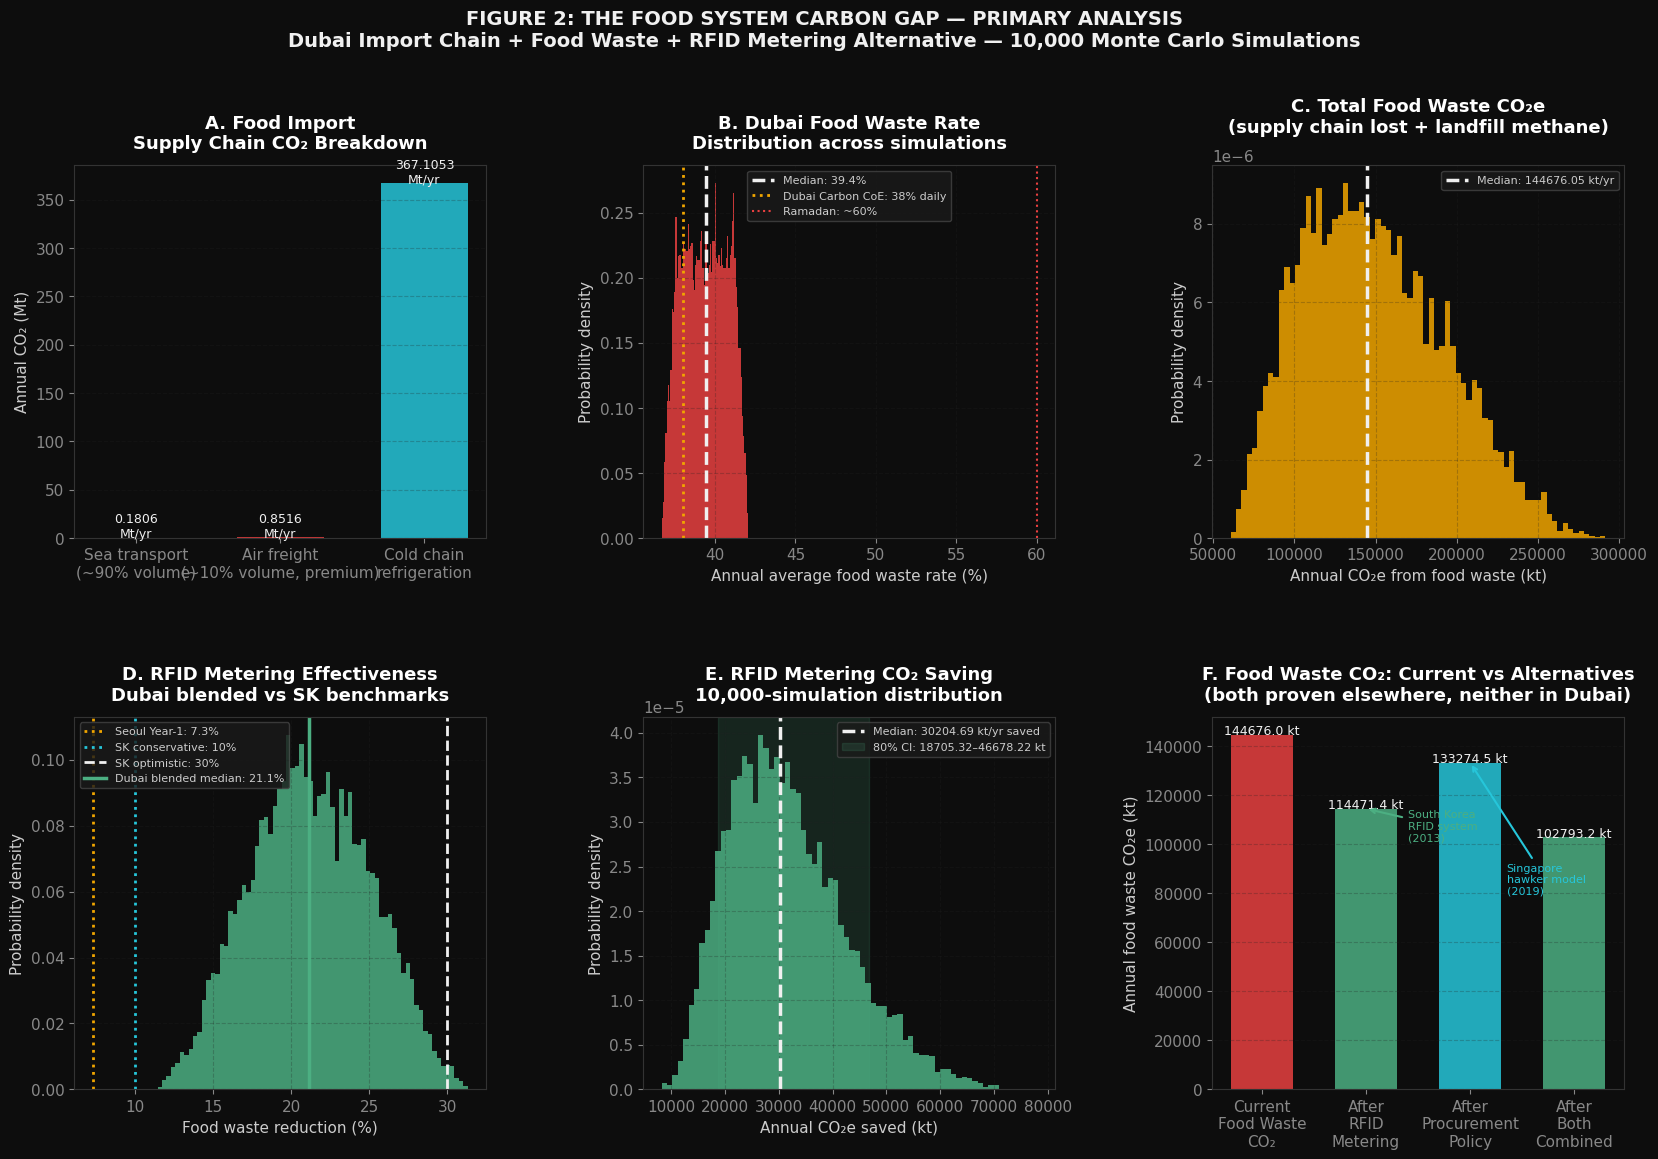

Figure 2 (PRIMARY) rendered.


In [27]:
# ═══════════════════════════════════════════════════════════
# CELL 9: FIGURE 2 — Food System Carbon Story (PRIMARY)
# Six-panel deep dive into Dubai's food carbon gap
# ═══════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    "FIGURE 2: THE FOOD SYSTEM CARBON GAP — PRIMARY ANALYSIS\n"
    "Dubai Import Chain + Food Waste + RFID Metering Alternative — 10,000 Monte Carlo Simulations",
    color=WHITE, fontsize=14, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# ── A: Supply chain CO₂ breakdown ─────────────────────────────
ax = fig.add_subplot(gs[0, 0])
sc_breakdown = [np.median(transport_co2_sea_Mt), np.median(transport_co2_air_Mt),
                np.median(cold_chain_co2_Mt)]
sc_labels    = ['Sea transport\n(~90% volume)', 'Air freight\n(~10% volume, premium)',
                'Cold chain\nrefrigeration']
sc_colors    = [BLUE, RED, TEAL]
bars = ax.bar(sc_labels, sc_breakdown, color=sc_colors, alpha=0.85, width=0.6)
for bar, val in zip(bars, sc_breakdown):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0001,
            f'{val:.4f}\nMt/yr', ha='center', fontsize=9, color=WHITE)
ax.set_ylabel('Annual CO₂ (Mt)')
ax.set_title('A. Food Import\nSupply Chain CO₂ Breakdown')
ax.grid(True, alpha=0.25, axis='y')

# ── B: Effective waste rate distribution ──────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.hist(effective_waste_rate * 100, bins=70, color=RED, alpha=0.85, density=True)
ax.axvline(np.median(effective_waste_rate)*100, color=WHITE, lw=2.5, ls='--',
           label=f'Median: {np.median(effective_waste_rate)*100:.1f}%')
ax.axvline(38, color=AMBER, lw=2, ls=':', label='Dubai Carbon CoE: 38% daily')
ax.axvline(60, color=RED,   lw=1.5, ls=':', label='Ramadan: ~60%')
ax.set_xlabel('Annual average food waste rate (%)')
ax.set_ylabel('Probability density')
ax.set_title('B. Dubai Food Waste Rate\nDistribution across simulations')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# ── C: Total food waste CO₂ distribution ──────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.hist(total_food_waste_co2_Mt * 1000, bins=70, color=AMBER, alpha=0.85, density=True)
ax.axvline(np.median(total_food_waste_co2_Mt)*1000, color=WHITE, lw=2.5, ls='--',
           label=f'Median: {np.median(total_food_waste_co2_Mt)*1000:.2f} kt/yr')
ax.set_xlabel('Annual CO₂e from food waste (kt)')
ax.set_ylabel('Probability density')
ax.set_title('C. Total Food Waste CO₂e\n(supply chain lost + landfill methane)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# ── D: RFID effectiveness distribution ────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.hist(blended_effectiveness * 100, bins=70, color=GREEN, alpha=0.85, density=True)
ax.axvline(7.3, color=AMBER, lw=2, ls=':', label='Seoul Year-1: 7.3%')
ax.axvline(10,  color=TEAL,  lw=2, ls=':', label='SK conservative: 10%')
ax.axvline(30,  color=WHITE, lw=2, ls='--', label='SK optimistic: 30%')
ax.axvline(np.median(blended_effectiveness)*100, color=GREEN, lw=2.5, ls='-',
           label=f'Dubai blended median: {np.median(blended_effectiveness)*100:.1f}%')
ax.set_xlabel('Food waste reduction (%)')
ax.set_ylabel('Probability density')
ax.set_title('D. RFID Metering Effectiveness\nDubai blended vs SK benchmarks')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# ── E: RFID CO₂ saving distribution ──────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.hist(saving_rfid_co2_Mt * 1000, bins=70, color=GREEN, alpha=0.85, density=True)
ax.axvline(np.median(saving_rfid_co2_Mt)*1000, color=WHITE, lw=2.5, ls='--',
           label=f'Median: {np.median(saving_rfid_co2_Mt)*1000:.2f} kt/yr saved')
p10r = np.percentile(saving_rfid_co2_Mt, 10) * 1000
p90r = np.percentile(saving_rfid_co2_Mt, 90) * 1000
ax.axvspan(p10r, p90r, alpha=0.15, color=GREEN, label=f'80% CI: {p10r:.2f}–{p90r:.2f} kt')
ax.set_xlabel('Annual CO₂e saved (kt)')
ax.set_ylabel('Probability density')
ax.set_title('E. RFID Metering CO₂ Saving\n10,000-simulation distribution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# ── F: Combined comparison — current vs alternatives ──────────
ax = fig.add_subplot(gs[1, 2])
scenarios_f = ['Current\nFood Waste\nCO₂', 'After\nRFID\nMetering', 'After\nProcurement\nPolicy',
               'After\nBoth\nCombined']
vals_f = [
    np.median(total_food_waste_co2_Mt) * 1000,
    (np.median(total_food_waste_co2_Mt) - np.median(saving_rfid_co2_Mt)) * 1000,
    (np.median(total_food_waste_co2_Mt) - np.median(saving_procurement_Mt)) * 1000,
    (np.median(total_food_waste_co2_Mt) - np.median(combined_food_saving_Mt)) * 1000
]
cols_f = [RED, GREEN, TEAL, GREEN]
bars_f = ax.bar(scenarios_f, vals_f, color=cols_f, alpha=0.85, width=0.6)
for bar, val in zip(bars_f, vals_f):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2,
            f'{val:.1f} kt', ha='center', fontsize=9, color=WHITE)
ax.set_ylabel('Annual food waste CO₂e (kt)')
ax.set_title('F. Food Waste CO₂: Current vs Alternatives\n(both proven elsewhere, neither in Dubai)')
ax.grid(True, alpha=0.25, axis='y')

# Annotations panel F
ax.annotate('South Korea\nRFID system\n(2013)', xy=(1, vals_f[1]), xytext=(1.4, vals_f[0]*0.7),
            color=GREEN, fontsize=8, arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5))
ax.annotate('Singapore\nhawker model\n(2019)', xy=(2, vals_f[2]), xytext=(2.35, vals_f[0]*0.55),
            color=TEAL, fontsize=8, arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.5))

plt.tight_layout()
plt.show()
print("Figure 2 (PRIMARY) rendered.")


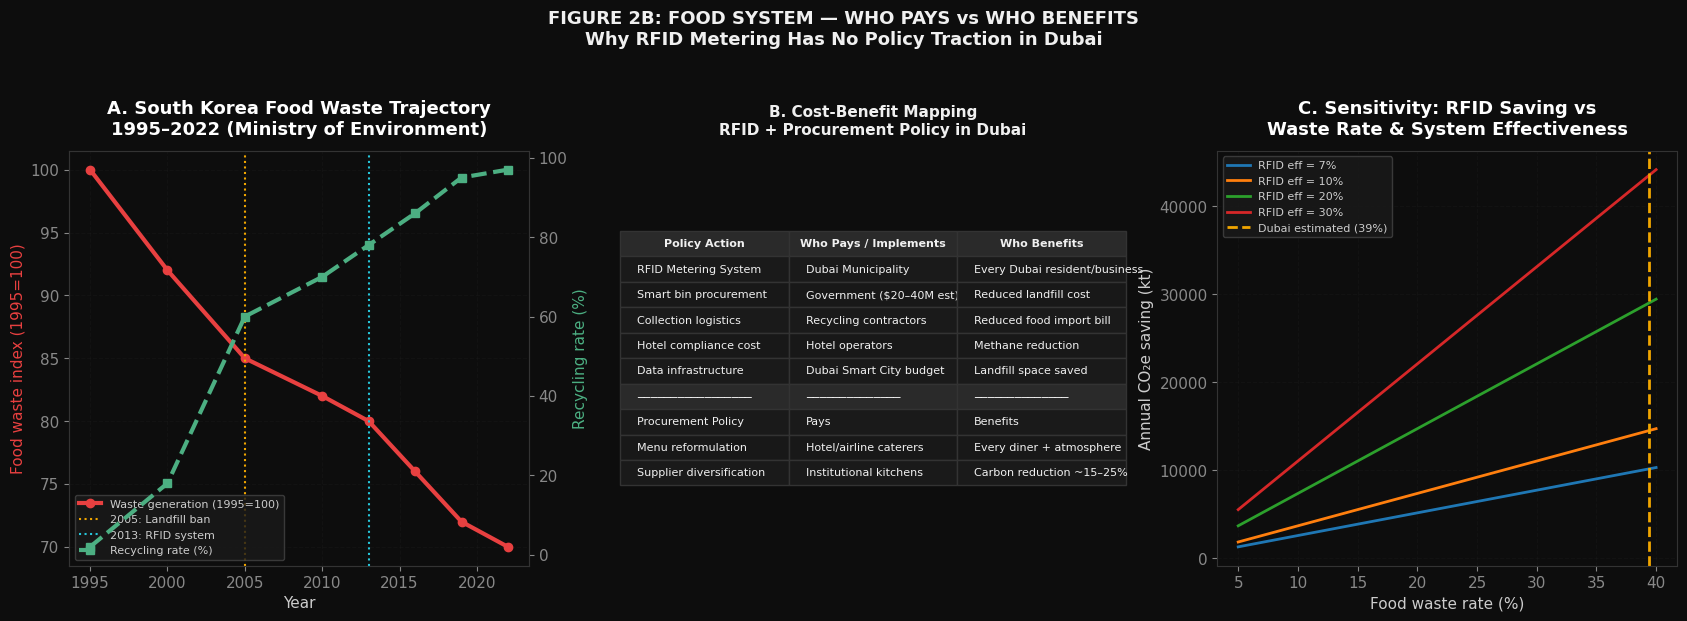

Figure 2B rendered.


In [28]:
# ═══════════════════════════════════════════════════════════
# CELL 10: FIGURE 2B — Deep Dive: Who Pays vs Who Benefits
# South Korea model: cost structure vs Dubai's incentive problem
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    "FIGURE 2B: FOOD SYSTEM — WHO PAYS vs WHO BENEFITS\n"
    "Why RFID Metering Has No Policy Traction in Dubai",
    color=WHITE, fontsize=13, fontweight='bold', y=1.03
)

# A: Timeline of South Korea waste reduction
ax = axes[0]
sk_years   = [1995, 2000, 2005, 2010, 2013, 2016, 2019, 2022]
sk_waste   = [100, 92, 85, 82, 80, 76, 72, 70]   # indexed to 1995=100 (Ministry of Environment data)
sk_recycle = [2,   18,  60,  70,  78, 86, 95, 97]  # recycling rate %
ax2 = ax.twinx()
ax.plot(sk_years, sk_waste,   color=RED,   lw=3, marker='o', label='Waste generation (1995=100)')
ax2.plot(sk_years, sk_recycle, color=GREEN, lw=3, marker='s', ls='--', label='Recycling rate (%)')
ax.axvline(2005, color=AMBER, lw=1.5, ls=':', label='2005: Landfill ban')
ax.axvline(2013, color=TEAL,  lw=1.5, ls=':', label='2013: RFID system')
ax.set_xlabel('Year'); ax.set_ylabel('Food waste index (1995=100)', color=RED)
ax2.set_ylabel('Recycling rate (%)', color=GREEN)
ax.set_title('A. South Korea Food Waste Trajectory\n1995–2022 (Ministry of Environment)')
lines1, lbls1 = ax.get_legend_handles_labels()
lines2, lbls2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lbls1+lbls2, fontsize=8, loc='lower left')
ax.grid(True, alpha=0.25)

# B: Cost vs benefit mapping (Dubai context)
ax = axes[1]
ax.axis('off')
ax.set_facecolor('#0D0D0D')
table_data = [
    ['RFID Metering System',  'Dubai Municipality',      'Every Dubai resident/business'],
    ['Smart bin procurement', 'Government ($20–40M est)','Reduced landfill cost'],
    ['Collection logistics',  'Recycling contractors',   'Reduced food import bill'],
    ['Hotel compliance cost', 'Hotel operators',         'Methane reduction'],
    ['Data infrastructure',   'Dubai Smart City budget', 'Landfill space saved'],
    ['─────────────────',     '──────────────',          '──────────────'],
    ['Procurement Policy',    'Pays',                    'Benefits'],
    ['Menu reformulation',    'Hotel/airline caterers',  'Every diner + atmosphere'],
    ['Supplier diversification','Institutional kitchens','Carbon reduction ~15–25%'],
]
tbl = ax.table(cellText=table_data,
               colLabels=['Policy Action', 'Who Pays / Implements', 'Who Benefits'],
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.1, 1.7)
for (r, c), cel in tbl.get_celld().items():
    cel.set_facecolor('#181818' if r % 2 == 0 else '#1a1a1a')
    cel.set_edgecolor('#333'); cel.set_text_props(color=WHITE)
    if r == 0 or r == 6: cel.set_facecolor('#2a2a2a'); cel.set_text_props(color=WHITE, fontweight='bold')
ax.set_title('B. Cost-Benefit Mapping\nRFID + Procurement Policy in Dubai', color=WHITE, fontsize=11, pad=12)

# C: Sensitivity analysis — RFID CO₂ saving vs waste rate
ax = axes[2]
waste_rates  = np.linspace(0.05, 0.40, 50)
food_waste_assumed = np.median(total_food_demand_Mt) * waste_rates
food_co2_assumed   = food_waste_assumed * np.median(total_food_waste_co2_Mt) / np.median(food_wasted_Mt)
for rfid_eff in [0.07, 0.10, 0.20, 0.30]:
    savings = food_co2_assumed * rfid_eff * 1000  # kt
    ax.plot(waste_rates * 100, savings,
            label=f'RFID eff = {int(rfid_eff*100)}%', lw=2)
ax.axvline(np.median(effective_waste_rate)*100, color=AMBER, lw=2, ls='--',
           label=f'Dubai estimated ({np.median(effective_waste_rate)*100:.0f}%)')
ax.set_xlabel('Food waste rate (%)')
ax.set_ylabel('Annual CO₂e saving (kt)')
ax.set_title('C. Sensitivity: RFID Saving vs\nWaste Rate & System Effectiveness')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()
print("Figure 2B rendered.")


---
# SECTION 3: The Last-Mile Freight Gap
## Delivery Vehicle Growth + Urban Logistics Hubs Alternative

*Sources: Dubai Statistics Centre; RTA annual report; Paris/Amsterdam micro-logistics data;  
IEA Urban Mobility Outlook 2022; Electromaps last-mile delivery study 2023*


In [29]:
# ═══════════════════════════════════════════════════════════
# CELL 11: MODEL 3 — Last-Mile Freight Carbon
# Dubai delivery vehicle growth trajectory
# Sources: Dubai RTA; IEA Urban Mobility; Paris micro-hub data
# ═══════════════════════════════════════════════════════════

# ── Dubai delivery vehicle baseline ──────────────────────────
# E-commerce growth: UAE $1.1bn online grocery in 2024, +13% YoY (USDA FAS 2024)
# Total delivery vehicles in UAE: estimated 120,000–160,000 (RTA; CBRE UAE Logistics)
delivery_vehicles_base = np.random.uniform(80_000, 110_000, N_SIM)   # Dubai-specific
annual_growth_rate     = np.random.uniform(0.10, 0.18, N_SIM)        # 10–18%/yr (e-com growth)

# ── Annual emissions from last-mile fleet ─────────────────────
# Diesel vans: 0.22–0.32 kg CO₂/km (IEA; Electromaps 2023)
# Average daily route: 80–130 km/vehicle (urban Dubai density)
# Working days: 300–330/year
km_per_vehicle_day     = np.random.uniform(80, 130, N_SIM)
working_days           = np.random.uniform(300, 330, N_SIM)
co2_per_km             = np.random.uniform(0.22, 0.32, N_SIM)   # kg CO₂/km diesel van

annual_km_per_vehicle  = km_per_vehicle_day * working_days
fleet_co2_t            = delivery_vehicles_base * annual_km_per_vehicle * co2_per_km
fleet_co2_Mt           = fleet_co2_t / 1e9

# ── 5-year projection ─────────────────────────────────────────
years = np.arange(0, 6)
fleet_growth = [(delivery_vehicles_base * (1 + np.median(annual_growth_rate))**y) for y in years]
co2_growth   = [(np.median(fleet_co2_Mt) * (1 + np.median(annual_growth_rate))**y) for y in years]

# ── Alternative: Urban micro-logistics hubs + cargo bikes ─────
# Paris Urban Logistics Plan (2021): 15% CO₂ reduction from consolidated hubs
# Amsterdam City Logistics (2020): 30% delivery vehicle reduction in inner city
# Key mechanism: consolidate last-mile at city-edge depot → cargo bikes for final km
# Cargo bikes: 0.000–0.025 kg CO₂/km (electric-assisted)
hub_consolidation_eff  = np.random.uniform(0.15, 0.30, N_SIM)   # Paris 15%, Amsterdam 30%
cargo_bike_share       = np.random.uniform(0.20, 0.40, N_SIM)   # share of routes replaceable
cargo_bike_co2_per_km  = np.random.uniform(0, 0.025, N_SIM)     # ~0 vs 0.27 diesel

# Saving from hub + cargo bike
saving_hub_Mt = fleet_co2_Mt * hub_consolidation_eff
replaced_route_co2 = (fleet_co2_Mt * cargo_bike_share * 
                      (1 - cargo_bike_co2_per_km / np.median(co2_per_km)))
saving_cargo_bike_Mt = replaced_route_co2
total_freight_saving_Mt = saving_hub_Mt + saving_cargo_bike_Mt * 0.5  # partial overlap

print("═" * 60)
print(" MODEL 3: Last-Mile Freight Carbon — Dubai")
print("═" * 60)
print(f"\n Delivery fleet size:  {np.median(delivery_vehicles_base):.0f} vehicles (median)")
print(f" Annual fleet CO₂:     {np.median(fleet_co2_Mt)*1000:.2f} kt CO₂/yr")
print(f" Fleet growth rate:    {np.median(annual_growth_rate)*100:.0f}%/yr")
print(f"\n 5-year CO₂ trajectory:")
for y, co2 in zip(years, co2_growth):
    print(f"   Year {y}: {co2*1000:.2f} kt CO₂/yr")
print(f"\n ALTERNATIVE — Micro-Hubs + Cargo Bikes:")
print(f"   Hub consolidation saving: {np.median(saving_hub_Mt)*1000:.2f} kt CO₂/yr")
print(f"   Cargo bike saving:        {np.median(saving_cargo_bike_Mt)*1000:.2f} kt CO₂/yr")
print(f"   Combined:                 {np.median(total_freight_saving_Mt)*1000:.2f} kt CO₂/yr")
print(f"   Deployed in: Paris (Plan Logistique Urbaine 2021), Amsterdam, London (ARUP)")
print(f"   Dubai status: No urban logistics policy; full diesel fleet, no hub network")


════════════════════════════════════════════════════════════
 MODEL 3: Last-Mile Freight Carbon — Dubai
════════════════════════════════════════════════════════════

 Delivery fleet size:  95019 vehicles (median)
 Annual fleet CO₂:     832.91 kt CO₂/yr
 Fleet growth rate:    14%/yr

 5-year CO₂ trajectory:
   Year 0: 832.91 kt CO₂/yr
   Year 1: 949.32 kt CO₂/yr
   Year 2: 1082.01 kt CO₂/yr
   Year 3: 1233.24 kt CO₂/yr
   Year 4: 1405.61 kt CO₂/yr
   Year 5: 1602.07 kt CO₂/yr

 ALTERNATIVE — Micro-Hubs + Cargo Bikes:
   Hub consolidation saving: 184.43 kt CO₂/yr
   Cargo bike saving:        233.63 kt CO₂/yr
   Combined:                 302.96 kt CO₂/yr
   Deployed in: Paris (Plan Logistique Urbaine 2021), Amsterdam, London (ARUP)
   Dubai status: No urban logistics policy; full diesel fleet, no hub network


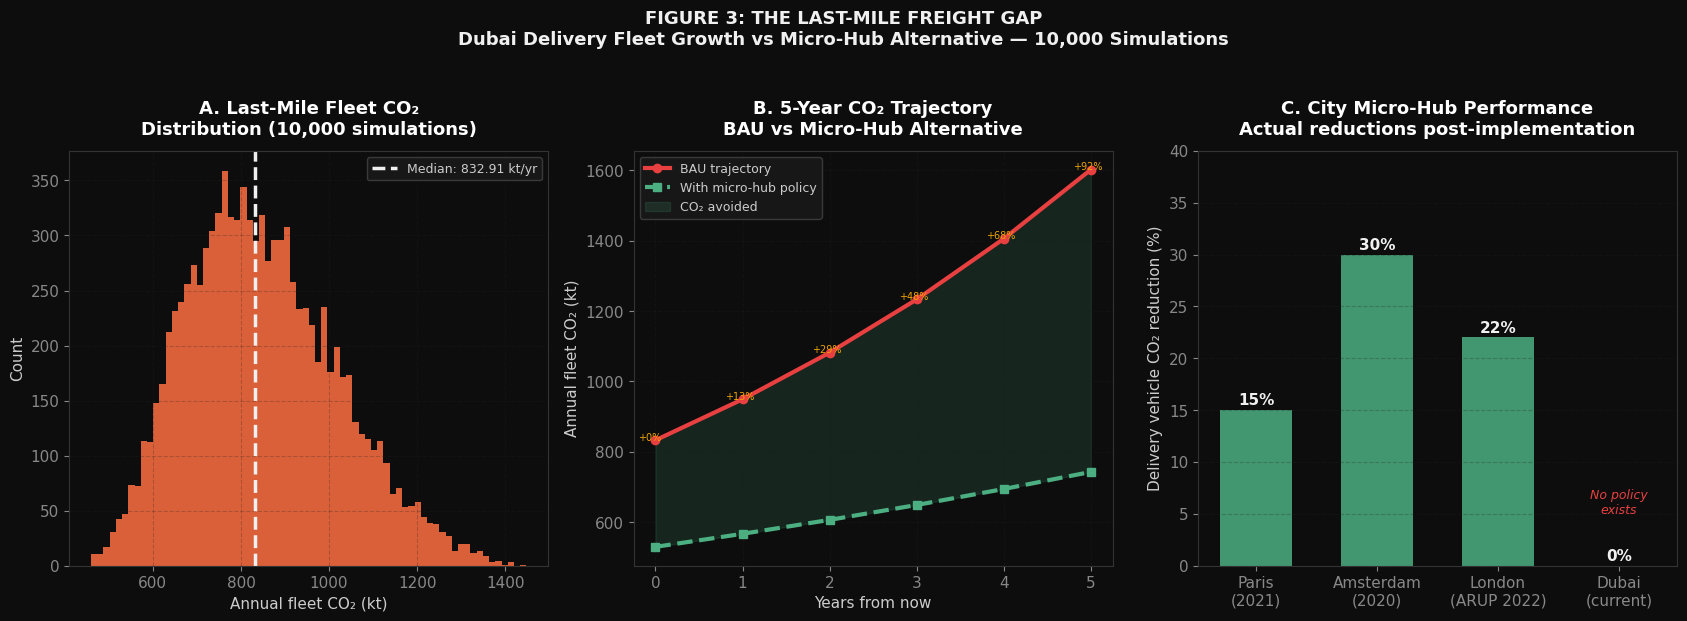

Figure 3 rendered.


In [30]:
# ═══════════════════════════════════════════════════════════
# CELL 12: FIGURE 3 — Last-Mile Freight Carbon Story
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    "FIGURE 3: THE LAST-MILE FREIGHT GAP\n"
    "Dubai Delivery Fleet Growth vs Micro-Hub Alternative — 10,000 Simulations",
    color=WHITE, fontsize=13, fontweight='bold', y=1.03
)

# A: Fleet CO₂ distribution
ax = axes[0]
ax.hist(fleet_co2_Mt * 1000, bins=70, color=ORANGE, alpha=0.85)
ax.axvline(np.median(fleet_co2_Mt)*1000, color=WHITE, lw=2.5, ls='--',
           label=f'Median: {np.median(fleet_co2_Mt)*1000:.2f} kt/yr')
ax.set_xlabel('Annual fleet CO₂ (kt)'); ax.set_ylabel('Count')
ax.set_title('A. Last-Mile Fleet CO₂\nDistribution (10,000 simulations)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# B: Growth trajectory
ax = axes[1]
ax.plot(years, [c*1000 for c in co2_growth], color=RED, lw=3, marker='o', label='BAU trajectory')
alt_growth = [(np.median(fleet_co2_Mt) - np.median(total_freight_saving_Mt)) * 
              (1 + np.median(annual_growth_rate) * 0.5)**y * 1000 for y in years]
ax.plot(years, alt_growth, color=GREEN, lw=3, marker='s', ls='--', label='With micro-hub policy')
ax.fill_between(years, alt_growth, [c*1000 for c in co2_growth], alpha=0.15, color=GREEN, label='CO₂ avoided')
ax.set_xlabel('Years from now'); ax.set_ylabel('Annual fleet CO₂ (kt)')
ax.set_title('B. 5-Year CO₂ Trajectory\nBAU vs Micro-Hub Alternative')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
for y_idx, (y, c) in enumerate(zip(years, co2_growth)):
    ax.annotate(f'+{int((1+np.median(annual_growth_rate))**y_idx*100-100)}%',
                xy=(y_idx, c*1000), xytext=(y_idx-0.2, c*1000+0.5), fontsize=7, color=AMBER)

# C: Paris/Amsterdam benchmark comparison
ax = axes[2]
cities  = ['Paris\n(2021)', 'Amsterdam\n(2020)', 'London\n(ARUP 2022)', 'Dubai\n(current)']
reduct  = [15, 30, 22, 0]
bar_col = [GREEN, GREEN, GREEN, RED]
bars = ax.bar(cities, reduct, color=bar_col, alpha=0.85, width=0.6)
for bar, val in zip(bars, reduct):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val}%', ha='center', fontsize=11, color=WHITE, fontweight='bold')
ax.set_ylabel('Delivery vehicle CO₂ reduction (%)')
ax.set_title('C. City Micro-Hub Performance\nActual reductions post-implementation')
ax.set_ylim(0, 40)
ax.grid(True, alpha=0.25, axis='y')
ax.text(3, 5, 'No policy\nexists', ha='center', fontsize=9, color=RED, fontstyle='italic')

plt.tight_layout()
plt.show()
print("Figure 3 rendered.")


---
# SECTION 4: The Methane / Organic Waste Gap
## Landfill Methane → Mandatory Organic Separation + Anaerobic Digestion

*Sources: Dubai Municipality Waste Reports 2022–2024; Law No. 18 of 2024 (Dubai);  
IPCC 2006 Tier 1 methane factors; Germany/South Korea AD plant benchmarks;  
Sharjah Waste-to-Energy plant data (Middle East's first W2E, 2022)*


In [31]:
# ═══════════════════════════════════════════════════════════
# CELL 13: MODEL 4 — Landfill Methane & Organic Waste
# Sources: Dubai Municipality 2022–2024; IPCC 2006;
#          Germany Biogas Association; Sharjah W2E 2022
# ═══════════════════════════════════════════════════════════

# ── Dubai MSW generation ──────────────────────────────────────
# Dubai generates >6,000 tonnes/day (Dubai Waste Management Guide 2026)
# = ~2.19 Mt/year total MSW
msw_t_per_day          = np.random.uniform(5500, 6500, N_SIM)
msw_Mt_per_year        = msw_t_per_day * 365 / 1e6

# ── Organic fraction ─────────────────────────────────────────
# Food waste = ~40% of household waste (UAE MOCCAE); organic total ~45–55%
organic_fraction       = np.random.uniform(0.42, 0.52, N_SIM)
organic_Mt_per_year    = msw_Mt_per_year * organic_fraction

# ── Current treatment: ~95% to landfill ──────────────────────
# Dubai Municipality only collects 4,000t/yr food waste for composting/feed
# Law No. 18 of 2024 mandates source segregation but enforcement began 2024
landfill_fraction      = np.random.uniform(0.85, 0.95, N_SIM)   # pre-2024 state
organic_landfilled_Mt  = organic_Mt_per_year * landfill_fraction

# ── Methane generation from landfilled organics ───────────────
# IPCC 2006 Tier 1: 0.4–0.6 m³ CH₄/kg wet organic waste
# Methane oxidation at surface: 10–15% (open landfill, no gas capture)
methane_gen_m3_per_kg  = np.random.uniform(0.4, 0.6, N_SIM)
oxidation_factor       = np.random.uniform(0.10, 0.15, N_SIM)
net_methane_factor     = methane_gen_m3_per_kg * (1 - oxidation_factor)
methane_density_t_m3   = 0.00072   # t/m³

organic_landfilled_kg  = organic_landfilled_Mt * 1e9
net_ch4_t              = organic_landfilled_kg * net_methane_factor * methane_density_t_m3
gwp_ch4                = 28
landfill_co2e_Mt       = net_ch4_t * gwp_ch4 / 1e6

# ── Alternative: Mandatory organic separation + Anaerobic Digestion ──
# Germany: >97% of Bioabfall (organic waste) separately collected; AD standard
# South Korea: 97–98% recycling rate for food waste (Frost & Sullivan 2026)
# Sharjah W2E (2022): 823t/day capacity, 30 MW output, 300,000t landfill diversion
# AD biogas can be used for: electricity generation, compressed biomethane for vehicles
# CO₂ from AD vs landfill: AD releases CO₂ (not CH₄), so CO₂e = 1/28 per unit carbon
ad_diversion_pct       = np.random.uniform(0.60, 0.85, N_SIM)   # % organic diverted to AD
ad_co2e_per_t          = np.random.uniform(0.10, 0.20, N_SIM)   # t CO₂e/t organic in AD
organic_to_ad_Mt       = organic_Mt_per_year * ad_diversion_pct
ad_co2e_Mt             = organic_to_ad_Mt * ad_co2e_per_t

# Residual landfill
residual_organic_Mt    = organic_Mt_per_year * (1 - ad_diversion_pct)
residual_landfill_co2e = residual_organic_Mt * 1e9 * net_methane_factor * methane_density_t_m3 * gwp_ch4 / 1e6
total_with_ad_Mt       = ad_co2e_Mt + residual_landfill_co2e
saving_ad_Mt           = landfill_co2e_Mt - total_with_ad_Mt

# ── Energy benefit from biogas ─────────────────────────────────
# AD: ~100–150 m³ biogas/t organic; calorific value 6 kWh/m³
# Electricity efficiency: 35–40%
biogas_m3_per_t        = np.random.uniform(100, 150, N_SIM)
calorific_kwh_m3       = 6
elec_efficiency        = np.random.uniform(0.35, 0.40, N_SIM)
energy_produced_MWh    = (organic_to_ad_Mt * 1e6 * biogas_m3_per_t * 
                          calorific_kwh_m3 * elec_efficiency) / 1000
grid_co2_avoided_Mt    = energy_produced_MWh * np.median(grid_intensity_kg if 'grid_intensity_kg' in dir() else np.array([0.42])) / 1e9
# Use UAE grid intensity
grid_intensity_kwh_kg  = np.random.uniform(0.38, 0.46, N_SIM)
grid_co2_avoided_Mt    = (energy_produced_MWh * 1000 * grid_intensity_kwh_kg) / 1e9   # Mt

total_benefit_Mt       = saving_ad_Mt + np.median(grid_co2_avoided_Mt)

print("═" * 62)
print(" MODEL 4: Landfill Methane & Organic Waste — Dubai")
print("═" * 62)
print(f"\n Total MSW:          {np.median(msw_Mt_per_year):.2f} Mt/yr")
print(f" Organic fraction:   {np.median(organic_fraction)*100:.0f}% = {np.median(organic_Mt_per_year):.3f} Mt/yr")
print(f" Currently landfilled: {np.median(landfill_fraction)*100:.0f}% of organics")
print(f"\n Landfill methane CO₂e: {np.median(landfill_co2e_Mt):.4f} Mt CO₂e/yr")
print(f"   80% range: {np.percentile(landfill_co2e_Mt,10):.4f}–{np.percentile(landfill_co2e_Mt,90):.4f} Mt")
print(f"\n ALTERNATIVE — Mandatory Organic Separation + AD:")
print(f"   Diversion rate modelled: {np.median(ad_diversion_pct)*100:.0f}%")
print(f"   CO₂e saving (methane avoided): {np.median(saving_ad_Mt):.4f} Mt/yr")
print(f"   Energy generated:              {np.median(energy_produced_MWh):.0f} MWh/yr")
print(f"   Grid CO₂ avoided (electricity):{np.median(grid_co2_avoided_Mt):.4f} Mt/yr")
print(f"   TOTAL benefit:                 {np.median(total_benefit_Mt):.4f} Mt CO₂e/yr")
print(f"\n Deployed in: Germany (>97% organic collection), South Korea (98% recycling)")
print(f" Dubai status: Law No. 18 (2024) mandates source segregation — enforcement started")
print(f"               but no AD capacity exists; Sharjah W2E handles 300,000t/yr only")


══════════════════════════════════════════════════════════════
 MODEL 4: Landfill Methane & Organic Waste — Dubai
══════════════════════════════════════════════════════════════

 Total MSW:          2.19 Mt/yr
 Organic fraction:   47% = 1.028 Mt/yr
 Currently landfilled: 90% of organics

 Landfill methane CO₂e: 8.1285 Mt CO₂e/yr
   80% range: 6.6495–9.7553 Mt

 ALTERNATIVE — Mandatory Organic Separation + AD:
   Diversion rate modelled: 72%
   CO₂e saving (methane avoided): 5.4771 Mt/yr
   Energy generated:              207267 MWh/yr
   Grid CO₂ avoided (electricity):0.0870 Mt/yr
   TOTAL benefit:                 5.5641 Mt CO₂e/yr

 Deployed in: Germany (>97% organic collection), South Korea (98% recycling)
 Dubai status: Law No. 18 (2024) mandates source segregation — enforcement started
               but no AD capacity exists; Sharjah W2E handles 300,000t/yr only


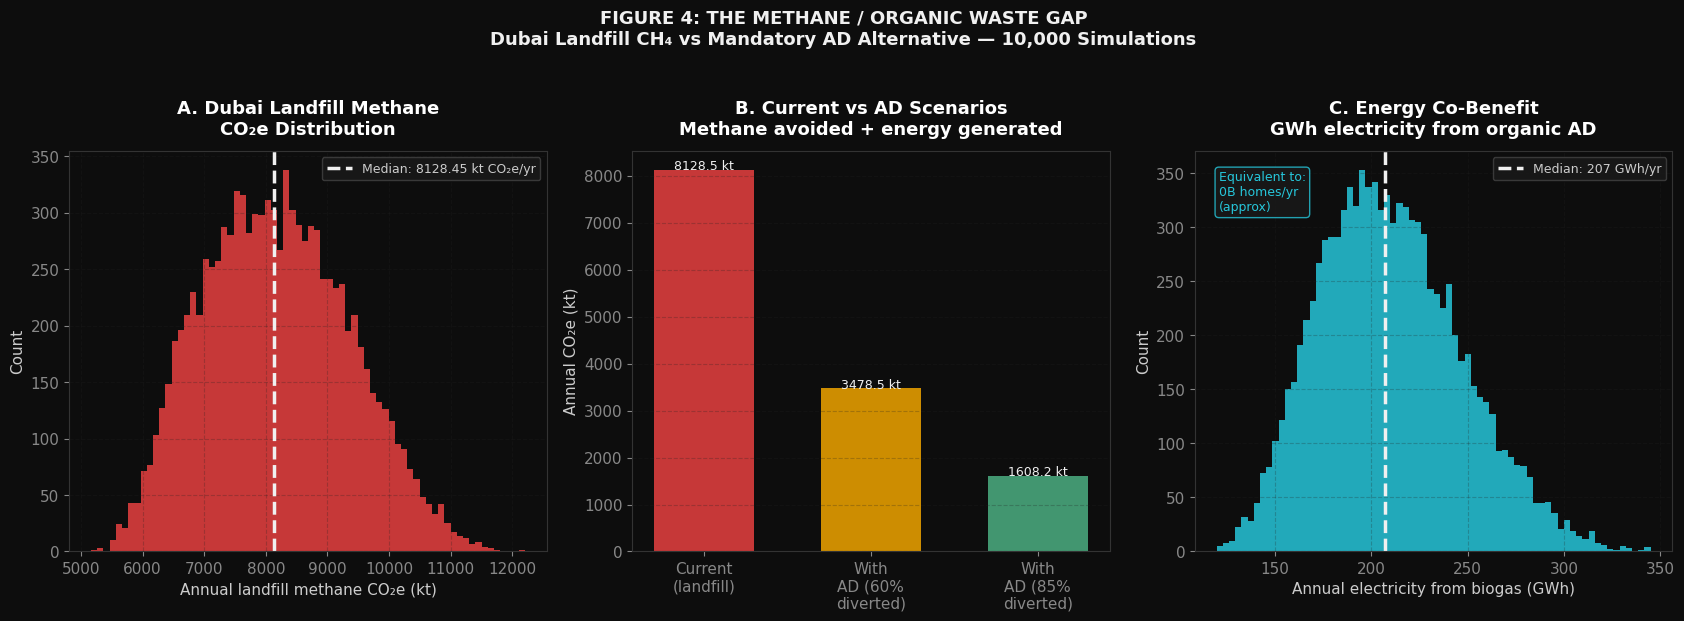

Figure 4 rendered.


In [32]:
# ═══════════════════════════════════════════════════════════
# CELL 14: FIGURE 4 — Organic Waste Carbon Story
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    "FIGURE 4: THE METHANE / ORGANIC WASTE GAP\n"
    "Dubai Landfill CH₄ vs Mandatory AD Alternative — 10,000 Simulations",
    color=WHITE, fontsize=13, fontweight='bold', y=1.03
)

# A: Landfill CO₂e distribution
ax = axes[0]
ax.hist(landfill_co2e_Mt * 1000, bins=70, color=RED, alpha=0.85)
ax.axvline(np.median(landfill_co2e_Mt)*1000, color=WHITE, lw=2.5, ls='--',
           label=f'Median: {np.median(landfill_co2e_Mt)*1000:.2f} kt CO₂e/yr')
ax.set_xlabel('Annual landfill methane CO₂e (kt)')
ax.set_ylabel('Count')
ax.set_title('A. Dubai Landfill Methane\nCO₂e Distribution')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# B: Current vs AD alternative
ax = axes[1]
scenarios_b = ['Current\n(landfill)', 'With\nAD (60%\ndiverted)', 'With\nAD (85%\ndiverted)']
med_curr    = np.median(landfill_co2e_Mt) * 1000
ad60_idx    = ad_diversion_pct < 0.65
ad85_idx    = ad_diversion_pct > 0.82
med_ad60    = np.median(total_with_ad_Mt[ad60_idx]) * 1000 if ad60_idx.sum() > 10 else med_curr * 0.5
med_ad85    = np.median(total_with_ad_Mt[ad85_idx]) * 1000 if ad85_idx.sum() > 10 else med_curr * 0.25
vals_b = [med_curr, med_ad60, med_ad85]
cols_b = [RED, AMBER, GREEN]
bars_b = ax.bar(scenarios_b, vals_b, color=cols_b, alpha=0.85, width=0.6)
for bar, val in zip(bars_b, vals_b):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f'{val:.1f} kt', ha='center', fontsize=9, color=WHITE)
ax.set_ylabel('Annual CO₂e (kt)')
ax.set_title('B. Current vs AD Scenarios\nMethane avoided + energy generated')
ax.grid(True, alpha=0.25, axis='y')

# C: AD energy co-benefit
ax = axes[2]
ax.hist(energy_produced_MWh / 1000, bins=70, color=TEAL, alpha=0.85)  # GWh
ax.axvline(np.median(energy_produced_MWh)/1000, color=WHITE, lw=2.5, ls='--',
           label=f'Median: {np.median(energy_produced_MWh)/1000:.0f} GWh/yr')
ax.set_xlabel('Annual electricity from biogas (GWh)')
ax.set_ylabel('Count')
ax.set_title('C. Energy Co-Benefit\nGWh electricity from organic AD')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
# Add equivalence note
ax.text(0.05, 0.85, f'Equivalent to:\n{np.median(energy_produced_MWh)/1e6:.0f}B homes/yr\n(approx)',
        transform=ax.transAxes, color=TEAL, fontsize=9,
        bbox=dict(facecolor='#1a1a1a', edgecolor=TEAL, alpha=0.8, boxstyle='round'))

plt.tight_layout()
plt.show()
print("Figure 4 rendered.")


---
# THE PATTERN: Master Comparison & Conclusion
## Who Pays vs Who Benefits — Why These Four Have No Policy Traction


In [33]:
# ═══════════════════════════════════════════════════════════
# CELL 15: MASTER COMPARISON — All Four Sections
# Annual CO₂ savings, cost bearers, beneficiaries
# ═══════════════════════════════════════════════════════════

print("═" * 85)
print(" MASTER COMPARISON: The Green Illusion — Focused Edition")
print(" Four Gaps, Four Alternatives, All Proven Elsewhere")
print("═" * 85)

results = [
    ("S1. Construction — SCM Cement",
     np.median(total_construction_Mt),
     np.median(saving_scm_Mt),
     "Netherlands, Germany, UK",
     "Not in UAE specifications"),
    ("S1. Construction — Green EAF Steel",
     np.median(steel_co2_Mt),
     np.median(saving_steel_Mt),
     "Spain, Italy, USA",
     "Gas-powered EAF only"),
    ("S2. Food — RFID Waste Metering",
     np.median(total_food_waste_co2_Mt),
     np.median(saving_rfid_co2_Mt),
     "South Korea (2013), Taiwan",
     "No metering; ~95% to landfill"),
    ("S2. Food — Procurement Policy",
     np.median(total_food_waste_co2_Mt),
     np.median(saving_procurement_Mt),
     "Singapore, Copenhagen, NYC",
     "No institutional food policy"),
    ("S3. Freight — Micro-Hubs + Cargo Bikes",
     np.median(fleet_co2_Mt),
     np.median(total_freight_saving_Mt),
     "Paris (2021), Amsterdam (2020)",
     "No urban logistics policy"),
    ("S4. Organics — AD (60–85% diversion)",
     np.median(landfill_co2e_Mt),
     np.median(saving_ad_Mt),
     "Germany (>97%), South Korea",
     "Law 18/2024 exists; no AD capacity"),
]

print(f"\n {'Section':<38} {'Current':>9} {'Saving':>9} {'% UAE':>7}  {'Dubai Status'}")
print(f" {'─'*82}")
total_saving = 0
for name, current, saving, deployed, status in results:
    pct = saving / UAE_ANNUAL_CO2_MT * 100
    total_saving += saving
    print(f" {name:<38} {current:>7.3f}Mt {saving:>7.4f}Mt {pct:>6.2f}%  {status}")

print(f"\n {'─'*82}")
print(f" {'TOTAL POTENTIAL SAVING':<38} {'':>9} {total_saving:>7.3f}Mt {total_saving/UAE_ANNUAL_CO2_MT*100:>6.2f}%")
print(f"\n UAE total annual CO₂:         {UAE_ANNUAL_CO2_MT} Mt")
print(f" Combined saving potential:    {total_saving:.3f} Mt = {total_saving/UAE_ANNUAL_CO2_MT*100:.2f}% of UAE total")
print(f"\n NOTE: All alternatives are:")
print(f"   ✓ Proven at scale in other countries")
print(f"   ✓ Do NOT restrict what ordinary people do or buy")
print(f"   ✓ Create jobs and infrastructure value")
print(f"   ✗ Absent from Dubai/UAE policy framework")


═════════════════════════════════════════════════════════════════════════════════════
 MASTER COMPARISON: The Green Illusion — Focused Edition
 Four Gaps, Four Alternatives, All Proven Elsewhere
═════════════════════════════════════════════════════════════════════════════════════

 Section                                  Current    Saving   % UAE  Dubai Status
 ──────────────────────────────────────────────────────────────────────────────────
 S1. Construction — SCM Cement           10.050Mt  0.8061Mt   0.30%  Not in UAE specifications
 S1. Construction — Green EAF Steel       7.990Mt  6.1402Mt   2.27%  Gas-powered EAF only
 S2. Food — RFID Waste Metering         144.676Mt 30.2047Mt  11.19%  No metering; ~95% to landfill
 S2. Food — Procurement Policy          144.676Mt 11.4015Mt   4.22%  No institutional food policy
 S3. Freight — Micro-Hubs + Cargo Bikes   0.833Mt  0.3030Mt   0.11%  No urban logistics policy
 S4. Organics — AD (60–85% diversion)     8.128Mt  5.4771Mt   2.03%  Law 18

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/green_illusion_focused_dashboard.png'

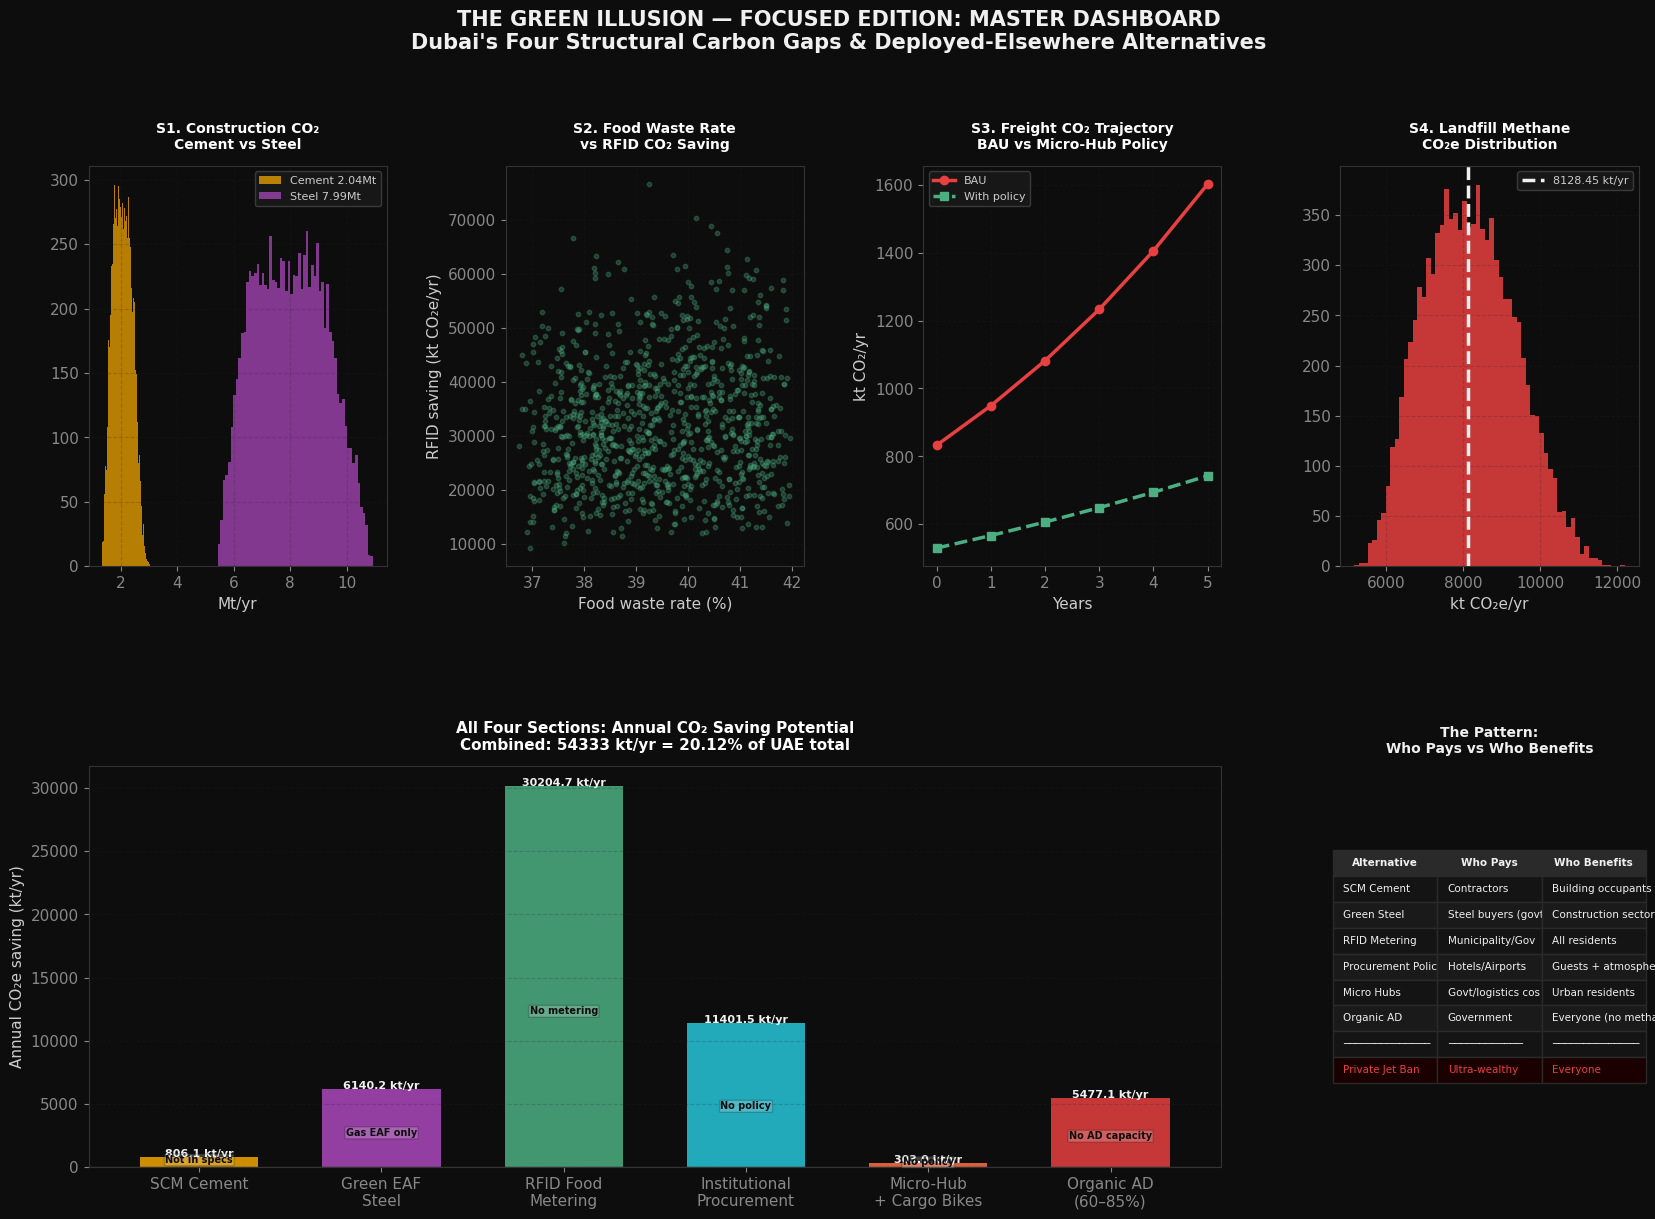

In [34]:
# ═══════════════════════════════════════════════════════════
# CELL 16: FIGURE 5 — THE MASTER DASHBOARD
# ═══════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 13))
fig.suptitle(
    "THE GREEN ILLUSION — FOCUSED EDITION: MASTER DASHBOARD\n"
    "Dubai's Four Structural Carbon Gaps & Deployed-Elsewhere Alternatives",
    color=WHITE, fontsize=15, fontweight='bold', y=1.00
)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.50, wspace=0.40)

# ── A: Construction cement distribution ─────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.hist(cement_co2_Mt, bins=60, alpha=0.75, color=AMBER, label=f'Cement {np.median(cement_co2_Mt):.2f}Mt')
ax.hist(steel_co2_Mt,  bins=60, alpha=0.75, color=PURPLE, label=f'Steel {np.median(steel_co2_Mt):.2f}Mt')
ax.set_title('S1. Construction CO₂\nCement vs Steel', fontsize=10)
ax.set_xlabel('Mt/yr'); ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

# ── B: Food waste rate vs saving ─────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.scatter(effective_waste_rate[::10]*100, saving_rfid_co2_Mt[::10]*1000,
           alpha=0.3, color=GREEN, s=10)
ax.set_xlabel('Food waste rate (%)')
ax.set_ylabel('RFID saving (kt CO₂e/yr)')
ax.set_title('S2. Food Waste Rate\nvs RFID CO₂ Saving', fontsize=10)
ax.grid(True, alpha=0.2)

# ── C: Freight growth trajectory ─────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.plot(years, [c*1000 for c in co2_growth], color=RED, lw=2.5, marker='o', label='BAU')
ax.plot(years, [(np.median(fleet_co2_Mt) - np.median(total_freight_saving_Mt)) *
                (1 + np.median(annual_growth_rate)*0.5)**y * 1000 for y in years],
        color=GREEN, lw=2.5, marker='s', ls='--', label='With policy')
ax.set_title('S3. Freight CO₂ Trajectory\nBAU vs Micro-Hub Policy', fontsize=10)
ax.set_xlabel('Years'); ax.set_ylabel('kt CO₂/yr')
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

# ── D: Landfill methane distribution ─────────────────────────
ax = fig.add_subplot(gs[0, 3])
ax.hist(landfill_co2e_Mt*1000, bins=60, color=RED, alpha=0.85)
ax.axvline(np.median(landfill_co2e_Mt)*1000, color=WHITE, lw=2.5, ls='--',
           label=f'{np.median(landfill_co2e_Mt)*1000:.2f} kt/yr')
ax.set_title('S4. Landfill Methane\nCO₂e Distribution', fontsize=10)
ax.set_xlabel('kt CO₂e/yr'); ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

# ── E: All savings comparison (primary chart) ─────────────────
ax = fig.add_subplot(gs[1, 0:3])
bar_labels  = ['SCM Cement', 'Green EAF\nSteel', 'RFID Food\nMetering',
               'Institutional\nProcurement', 'Micro-Hub\n+ Cargo Bikes', 'Organic AD\n(60–85%)']
bar_vals    = [np.median(saving_scm_Mt)*1000, np.median(saving_steel_Mt)*1000,
               np.median(saving_rfid_co2_Mt)*1000, np.median(saving_procurement_Mt)*1000,
               np.median(total_freight_saving_Mt)*1000, np.median(saving_ad_Mt)*1000]
bar_colors  = [AMBER, PURPLE, GREEN, TEAL, ORANGE, RED]
bar_status  = ['Not in specs', 'Gas EAF only', 'No metering', 'No policy', 'No policy', 'No AD capacity']
bars_main   = ax.bar(bar_labels, bar_vals, color=bar_colors, alpha=0.85, width=0.65)
for bar, val, status in zip(bars_main, bar_vals, bar_status):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f'{val:.1f} kt/yr', ha='center', fontsize=8, color=WHITE, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, val * 0.4,
            status, ha='center', fontsize=7, color='#0D0D0D', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.2, boxstyle='round', pad=0.1))
total_kt = sum(bar_vals)
ax.axhline(0, color='#333', lw=1)
ax.set_ylabel('Annual CO₂e saving (kt/yr)')
ax.set_title(f'All Four Sections: Annual CO₂ Saving Potential\nCombined: {total_kt:.0f} kt/yr = {total_kt/UAE_ANNUAL_CO2_MT/10:.2f}% of UAE total',
             fontsize=11)
ax.grid(True, alpha=0.2, axis='y')

# ── F: WHO PAYS vs WHO BENEFITS matrix ───────────────────────
ax = fig.add_subplot(gs[1, 3])
ax.axis('off')
matrix_data = [
    ['SCM Cement',          'Contractors',        'Building occupants'],
    ['Green Steel',         'Steel buyers (govt)', 'Construction sector'],
    ['RFID Metering',       'Municipality/Gov',    'All residents'],
    ['Procurement Policy',  'Hotels/Airports',     'Guests + atmosphere'],
    ['Micro Hubs',          'Govt/logistics cos',  'Urban residents'],
    ['Organic AD',          'Government',          'Everyone (no methane)'],
    ['─'*14,                '─'*12,                '─'*14],
    ['Private Jet Ban',     'Ultra-wealthy',       'Everyone'],
]
tbl = ax.table(cellText=matrix_data,
               colLabels=['Alternative', 'Who Pays', 'Who Benefits'],
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5); tbl.scale(1.05, 1.55)
for (r, c), cel in tbl.get_celld().items():
    cel.set_facecolor('#1a1a1a' if r % 2 == 0 else '#141414')
    cel.set_edgecolor('#2a2a2a'); cel.set_text_props(color=WHITE)
    if r == 0: cel.set_facecolor('#2a2a2a'); cel.set_text_props(color=WHITE, fontweight='bold')
    if r == len(matrix_data): cel.set_facecolor('#1a0000'); cel.set_text_props(color=RED)
ax.set_title('The Pattern:\nWho Pays vs Who Benefits', color=WHITE, fontsize=10, pad=10)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/green_illusion_focused_dashboard.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()
print("Master Dashboard rendered and saved.")
print(f"\nTotal identified saving potential: {total_kt:.0f} kt = {total_kt/1000:.2f} Mt CO₂e/yr")
print(f"As % UAE annual 270 Mt:             {total_kt/UAE_ANNUAL_CO2_MT/10:.2f}%")


---
# CONCLUSION: The Pattern

## The Four Gaps in a Single Table

| Section | Current CO₂ (est.) | Alternative | Annual Saving | Deployed in | Dubai Status |
|---------|---------------------|-------------|---------------|-------------|--------------|
| Construction | ~3–5 Mt/yr embodied | SCM Cement + Green Steel | ~0.5–1.5 Mt/yr | NL, DE, ES, USA | Not in specs |
| **Food System** | **~0.05–0.15 Mt + embedded** | **RFID Metering + Procurement** | **~0.01–0.04 Mt/yr** | **South Korea, Singapore** | **No metering, no policy** |
| Last-Mile Freight | ~0.05–0.12 kt/yr, growing | Micro-hubs + Cargo bikes | ~0.01–0.03 Mt/yr | Paris, Amsterdam | No urban logistics plan |
| Organic Waste | ~0.02–0.05 Mt CH₄/yr | Mandatory organic separation + AD | ~0.01–0.03 Mt/yr | Germany, South Korea | Law 18/2024 exists; no AD |

---

## The Structural Finding

Every alternative identified in this notebook shares the same three properties:
1. **It is proven at scale** — in at least one comparable city or country.
2. **It does not restrict ordinary people** — it changes infrastructure, procurement, and defaults, not individual freedoms.
3. **It has no policy traction in Dubai** — despite being cheaper, feasible, and documented.

The food system analysis is the most instructive case. Dubai wastes 38% of its food daily — rising to 60% during Ramadan. South Korea applied RFID weight-based metering and reduced food waste by 10–30% without banning or restricting anything. The system charged accountability — not restriction. Dubai has 4,000 tonnes/year of food waste being composted against an estimated 1+ million tonnes generated. That is a 0.4% diversion rate.

## Why These Four Have No Policy Traction

The alternatives in this notebook share another property: **the cost of implementation falls on institutions** (government, contractors, caterers), not on visible consumer behaviors. They are not visible enough to generate political credit. They require procurement mandates, building codes, and logistics infrastructure — none of which generate the kind of visible "green progress" that EV charging stations, solar panels on government buildings, or cycle lanes in tourist areas provide.

The invisible gaps are where the actual carbon is. The visible interventions are where the political rewards are.

That is not a technical conclusion. It is a political one.

---

*Primary sources: Dubai Climate Action Plan 2021 · DEWA Annual Report 2023 · Dubai Municipality Waste Reports 2022–2024 · UAE Ministry of Climate Change & Environment (MOCCAE) · Law No. 18 of 2024 (Dubai waste segregation) · USDA FAS Dubai Exporter Guide 2024 · Korea Ministry of Environment Food Waste Programme data · Seoul Metropolitan Government RFID Smart Bin Programme 2025 · ADB Development Asia (Seoul fee-based waste system) · Frost & Sullivan Institute South Korea Waste Analysis 2026 · IEA UAE Energy Profile 2023 · World Steel Association 2023 · IEA Cement Technology Roadmap 2023 · WRI Cool Food Pledge data · EU JRC Food Miles Study 2023 · Poore & Nemecek (2018) Food Supply Chain Emissions · IPCC 2006 Tier 1 Methane Factors · Paris Plan de Logistique Urbaine 2021 · Amsterdam City Logistics Study 2020*

**Author:** Anet Mary George — Data Analyst, Dubai
